In [1]:
import pandas as pd 
import numpy as np
import os 
import xarray as xr 
import matplotlib.pyplot as plt
import cmocean as cmo 
import pandas as pd 
# import plotly.graph_objs as go
# from plotly.subplots import make_subplots
import numpy as np
import matplotlib.dates as mdates
import cmcrameri.cm as cmc

# Start date 
start_date = '2024-08-06'
end_date = '2024-08-28' 

Dates = pd.date_range(start_date, end_date, freq='10s')

import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

def format_date_ax(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

In [2]:
hydro = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/two_species/adjoint_phytoplankton/run_hydro/HYDRO_AUGUST6-28.nc")
htime = Dates

temp = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/turbulence-model/data/forcing_data/data/Temperature_processed.csv")
temp = temp.loc[temp.SITE == "WEB"]
temp = temp.loc[temp.STAT == "Average"]
temp.reset_index(inplace=True)
temp['time'] = pd.to_datetime(temp['TIMESTAMP'])
temp.drop(columns=['STAT', 'SITE', "SENSOR", "Interval", "TIMESTAMP"], inplace=True)
temp['day'] = temp['time'].dt.day
# print(temp)

# Chlorophyll-a data
chla = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-28/chla_for_adjoint.csv")
chla['time'] = pd.to_datetime(chla['time'])
obs = chla.pg_chla_perML 

# Rolling average to smooth the data
obs_roll = obs.rolling(window=10, center=True).mean()
chla['obs_roll'] = obs_roll
chla['day'] = chla['time'].dt.day

/tmp/ipykernel_368454/3317615317.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  hydro = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/two_species/adjoint_phytoplankton/run_hydro/HYDRO_AUGUST6-28.nc")


In [3]:
def get_dwl(day, time, T0):
    temp0 = temp.loc[temp.day == day]
    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)
    kernel2 = np.ones(4)/4
    averaged_md = np.convolve(md, kernel2, mode='same')

    mask = maxs>T0
    mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])
    if sum(mask)>2:
        difference = (pd.to_datetime(X[mask][-1]) - pd.to_datetime(X[mask][-2])) 
        if difference  > pd.Timedelta(hours=1):
            print("Warning: gap in DWL detection larger than 1 hour on day %d" % day)
            mask[np.where(X==X[mask][-1])[0][0]] = False

    return X, averaged_md, mask


In [4]:
days = range(6, 28)

days_fn = ["august_%02d" % day for day in days]
print(days_fn)

guess = {} 

# get list of files in finished/
read_in = os.listdir('finished2/')
print(read_in)

import re

for file in read_in:
    if file.startswith('forward_1_') or file.startswith('adjoint'):
        pass
    else:
        # print(file)
        match = re.search(r'(\d+)(?=\.nc$)', file)
        day = match.group(1)
        guess[day] = xr.open_dataset('finished2/%s' % (file), decode_timedelta=False)
        print("Opened day ", day)
        z = guess[day].z.values

    # Get last two digits 

# for i in read_in: #range(1, NITER):
#     guess[i] = xr.open_dataset('finished/forward__%s.nc' % (days_fn), decode_timedelta=False)

['august_06', 'august_07', 'august_08', 'august_09', 'august_10', 'august_11', 'august_12', 'august_13', 'august_14', 'august_15', 'august_16', 'august_17', 'august_18', 'august_19', 'august_20', 'august_21', 'august_22', 'august_23', 'august_24', 'august_25', 'august_26', 'august_27']
['forward_400_august_09.nc', 'forward_400_august_17.nc', 'adjoint_1_august_11.nc', 'forward_292_august_06.nc', 'adjoint_1_august_22.nc', 'forward_1_august_24.nc', 'forward_400_august_18.nc', 'forward_400_august_13.nc', 'forward_600_august_22.nc', 'adjoint_1_august_20.nc', 'forward_600_august_20.nc', 'forward_297_august_07.nc', 'forward_1_august_13.nc', 'forward_1_august_22.nc', 'forward_1_august_11.nc', 'forward_400_august_19.nc', 'adjoint_600_august_20.nc', 'adjoint_297_august_15.nc', 'adjoint_1_august_15.nc', 'adjoint_600_august_26.nc', 'adjoint_400_august_18.nc', 'forward_600_august_24.nc', 'adjoint_1_august_21.nc', 'forward_600_august_12.nc', 'adjoint_400_august_16.nc', 'forward_1_august_20.nc', 'adj

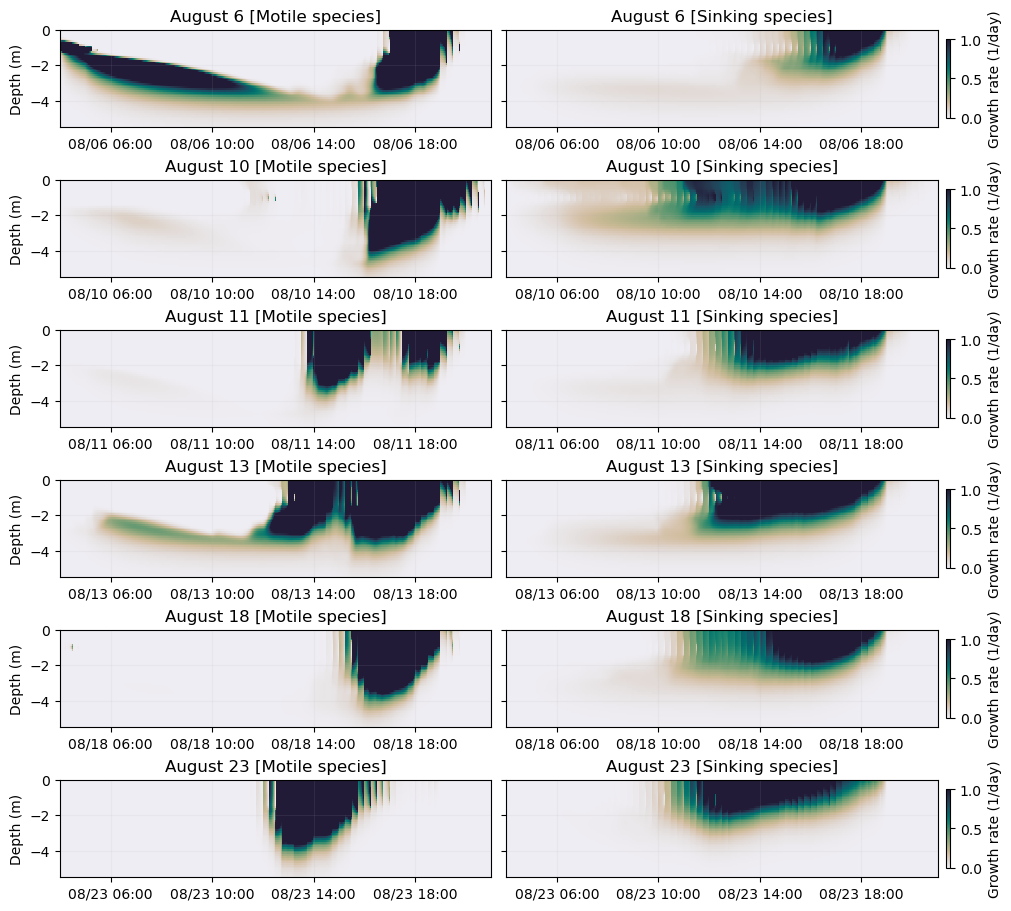

In [5]:
fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(10, 9), sharex=False, sharey=True, constrained_layout=True)
axs = axs.flatten()


days2plot = [6, 10, 11, 13, 18, 23] 
# days2plot = [7, 9, 11, 18, 13, 19,]
# days2plot = [24, 25, 26, 27]


           # 0 1 / 2 3 / 4 5 / 6 7 / 8 9 
for i,d in enumerate(days2plot):

    try:
        ds = guess["%02d" % (d)]
    except:
        continue 
    time = Dates[ds.t.values]

    h1 = axs[i*2].pcolormesh(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-0)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    h2 = axs[i*2 + 1].pcolormesh(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-0)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
        
    # plt.colorbar(h1, ax = axs[i*2], pad=2e-2, label="Growth rate (1/day)", shrink=0.8) #  ax=axs, orientation='horizontal', label='Growth rate (1/day)', 
    plt.colorbar(h2, ax = axs[i*2 +1], pad=2e-2, label="Growth rate (1/day)", shrink=0.8) #  ax=axs, orientation='horizontal', label='Growth rate (1/day)', 

    axs[i*2].grid(alpha=0.1)
    axs[i*2 + 1].grid(alpha=0.1)

    # axs[i].set_ylim(-5, 0)
    # format_date_ax(axs[i])
    axs[i*2].set_xlim(time[0], time[-1])

    axs[i*2 + 1].set_xlim(time[0], time[-1])
    axs[i*2].set_title("August %d [Motile species]" % d)
    axs[i*2].set_ylabel("Depth (m)")
    axs[i*2 + 1].set_title("August %d [Sinking species]" % d)

for ax in axs:
    ax.set_ylim(-5.5, 0)
    format_date_ax(ax)

fig.savefig("plots/PAPER_growth_rates_on_selected_days_Dec4.png", dpi=300)


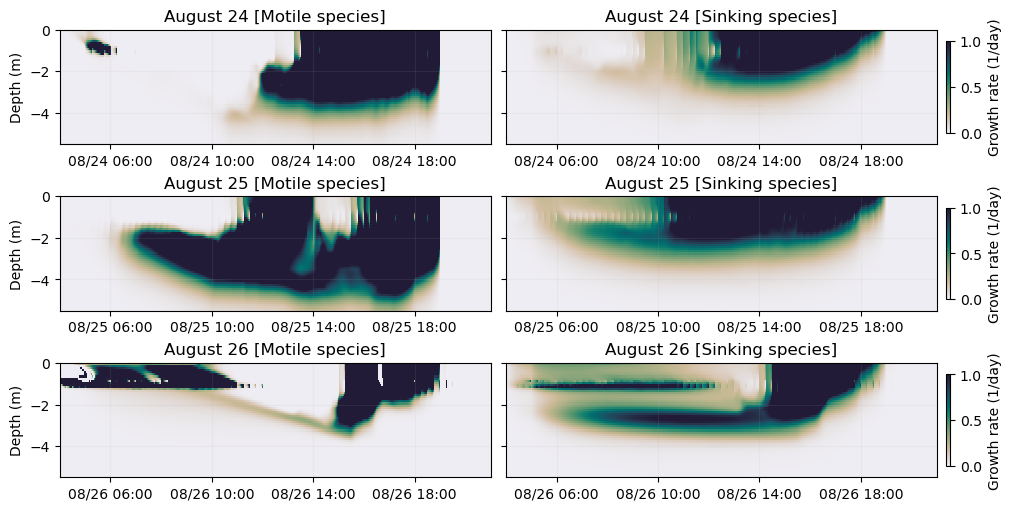

In [6]:
# Show full days

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 5), sharex=False, sharey=True, constrained_layout=True)
axs = axs.flatten()



for i,d in enumerate(np.arange(24, 27)):

    try:
        ds = guess["%02d" % (d)]
    except:
        continue 
    time = Dates[ds.t.values]

    h1 = axs[i*2].pcolormesh(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-0)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    h2 = axs[i*2 + 1].pcolormesh(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-0)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
        
    # plt.colorbar(h1, ax = axs[i*2], pad=2e-2, label="Growth rate (1/day)", shrink=0.8) #  ax=axs, orientation='horizontal', label='Growth rate (1/day)', 
    plt.colorbar(h2, ax = axs[i*2 +1], pad=2e-2, label="Growth rate (1/day)", shrink=0.8) #  ax=axs, orientation='horizontal', label='Growth rate (1/day)', 

    axs[i*2].grid(alpha=0.1)
    axs[i*2 + 1].grid(alpha=0.1)

    # axs[i].set_ylim(-5, 0)
    # format_date_ax(axs[i])
    axs[i*2].set_xlim(time[0], time[-1])

    axs[i*2 + 1].set_xlim(time[0], time[-1])
    axs[i*2].set_title("August %d [Motile species]" % d) #[$Microcystis$]" % d)
    axs[i*2].set_ylabel("Depth (m)")
    axs[i*2 + 1].set_title("August %d [Sinking species]" % d)

for ax in axs:
    ax.set_ylim(-5.5, 0)
    format_date_ax(ax)

fig.savefig("plots/growth_rates_FULL3.png", dpi=300)


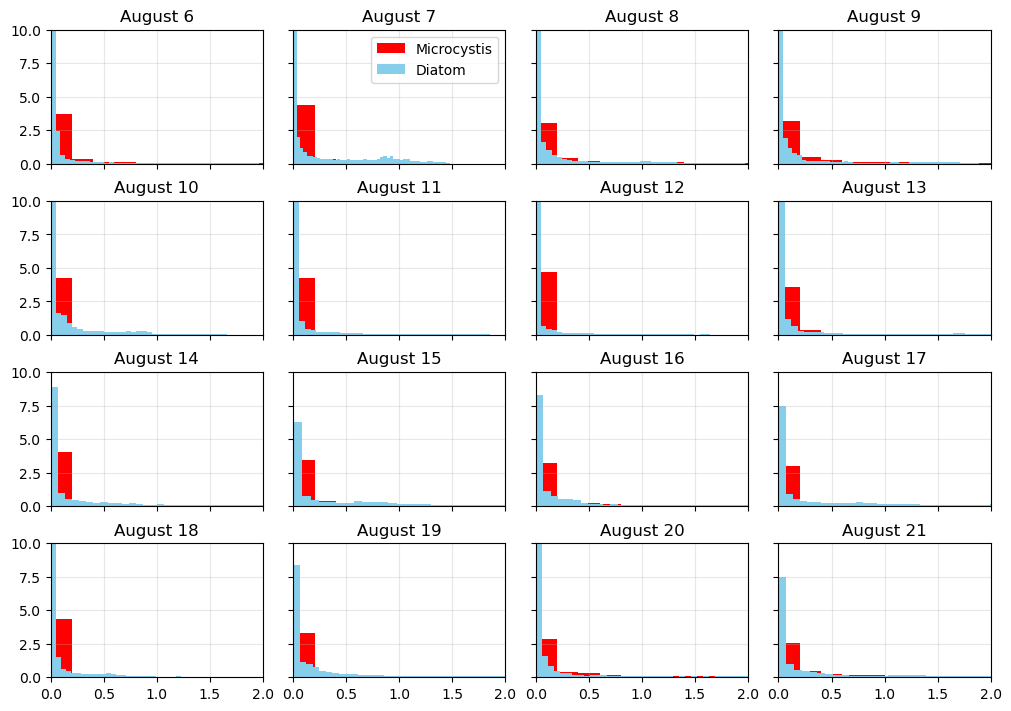

In [7]:
# # characterize growth at depths 


fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(10, 7), sharex=True, sharey=True, constrained_layout=True)
axs = axs.flatten()

days2plot = [9, 17, 18, 13, 19, 10]
           # 0 1 / 2 3 / 4 5 / 6 7 / 8 9 
for i,d in enumerate(np.arange(6,22)):

    try:
        ds = guess["%02d" % (d)]
    except:
        continue
    time = Dates[ds.t.values]

    limit = 10
    g1= ds.gamma1.values.ravel() * (86400)
    g1 = np.clip(g1, 0, limit)
    h1 = axs[i].hist(g1, density=True, bins =50, color="red", label="Microcystis") # , cmap=cmo.cm.rain, vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    # 
    g2 = ds.gamma2.values.ravel() * (86400)  
    g2 = np.clip(g2, 0, limit)
    h2 = axs[i].hist(g2, density=True, bins =50, color="skyblue", label="Diatom") # , cmap=cmo.cm.rain, vmin=0, vmax=1e-0)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)

    axs[i].set_xlim(0, 2)
    axs[i].set_ylim(0, 10)
    # axs[i].set_scale('log')
    axs[i].grid(alpha=0.3)
    axs[i].set_title("August %d" % d)

axs[1].legend()











    # axs[i].hist(d1, density=False, bins = 20, color="skyblue", label="Kz") # , cmap=cmo.cm.rain, vmin=0, vmax=1e-0)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)

    # # axs[i].set_xlim(0, limit)
    # # axs[i].set_ylim(0, 10)
    # axs[i].set_xscale('log')
    # axs[i].grid(alpha=0.3)
    # axs[i].set_title("August %d" % d)

# axs[0].legend()


#     axs[i*2 + 1].set_xlim(time[0], time[-1])
#     axs[i*2].set_title("August %d [$Microcystis$]" % d)
#     axs[i*2].set_ylabel("Depth (m)")
#     axs[i*2 + 1].set_title("August %d [Diatoms]" % d)

# for ax in axs:
#     ax.set_ylim(-4, 0)
#     format_date_ax(ax)


# plt.tight_layout()

# ax2.grid(alpha=0.3)
# ax2.set_ylabel("Depth (m)")
# ax2.set_xlabel("Hour of max growth (hours)")
# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
# # fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=2e-2)

In [8]:
# # characterize growth at depths 

# fig = plt.figure(figsize=(10,4)) 
# ax = plt.gca()

days_mc = [] 
days_dm = []
days_kz = [] 
days2plot =np.arange(6, 27) #[7, 9, 11, 13, 19, 23]
           # 0 1 / 2 3 / 4 5 / 6 7 / 8 9 
for i,d in enumerate(days2plot):

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]


    g1= ds.gamma1.values.ravel() * (86400)
    g1 = np.clip(g1,0, 20)
    g1 = g1[g1<20] 
    days_mc.append(g1)
    # 
    g2 = ds.gamma2.values.ravel()  * (86400)  
    g2 = g2[g2<20] 
    days_dm.append(g2)

    hydro0 = hydro.isel(time=ds.t.values)
    # hydro0 = hydro0.isel(time=np.arange(3122, 5122))
    d1 = hydro0['Kz'].values.ravel()
    days_kz.append(d1)


NameError: name 'duration' is not defined

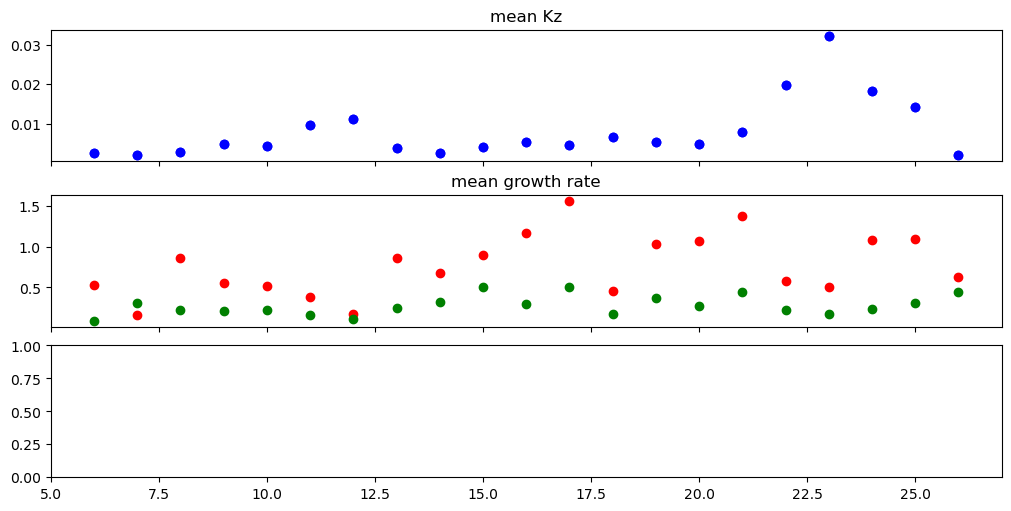

In [9]:
# # Stacked 
#
#test
figfig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5), sharex=True, sharey=False, constrained_layout=True)
# axs = axs.flatten()


for i,k in enumerate(days_kz):
    axs[0].plot(i+6, np.mean(k), '-o', color='blue')
    axs[0].plot(i+6, np.mean(k), '-o',color='blue')
    axs[1].plot(i+6, np.mean(days_mc[i]), '-o', color='red')
    axs[1].plot(i+6, np.mean(days_dm[i]), '-o', color='green')

axs[1].set_title("mean growth rate")
axs[0].set_title("mean Kz")

axs[2].plot(days2plot, duration, '-o', color='blue', label='Kz')
axs[2].set_title("duration")
axs[0].set_yscale('log')
h= axs[0].set_xticks(days2plot)
for ax in axs:
    ax.grid(alpha=0.5)
#     # ax.set_xscale("log")
#     # ax.set_yscale("log")
#     ax.grid(which='both', alpha=0.2)

# colors = cmc.hawaii(np.linspace(0,1,len(days_dm)))
# m = axs[0].hist(days_dm, stacked=True, density=True, bins=500, color=colors)


# m = axs[1].hist(days_mc, stacked=True, density=True, bins=50, color=colors) #, color=colors)



# axs[1].set_xlim(0, .1)
# # ax.grid(alpha=0.3)
# # ax.set_ylabel("Diffusivity (m$^2$/s)")
# # ax.set_xticks(days2plot)
# # ax.set_xlabel("Day in August, 2024")
# # plt.tight_layout()
# # fig.savefig("diffusivity_range.png")




In [ ]:
means = [np.mean(i) for i in days_mc]

index = np.argsort(means)
print(index)



[ 1  6  5 12 17  4  0  3 16 20  8  2  7  9 13 14 18 19 10 15 11]


TypeError: only integer scalar arrays can be converted to a scalar index

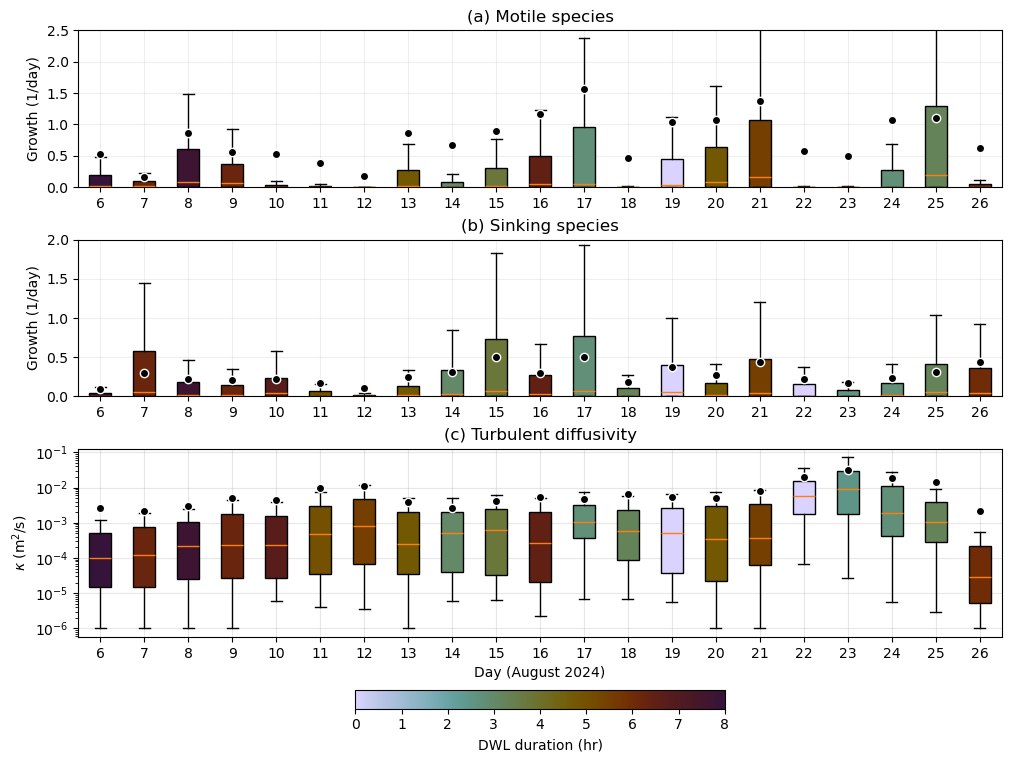

In [17]:
fig, axs = plt.subplots(nrows=3, ncols=1, sharey=False, figsize=(10,7.5), height_ratios=[1,1,1.2], constrained_layout=True)
axs = axs.flatten()


for ax in axs: 
    # ax2 = ax.twinx()
    # ax2.set_ylabel("DWL duration (hr)")
    # ax2.plot(np.arange(6,25)-5, duration, 'o-', color='#FC6E6D', label="DWL duration (hr)", linewidth=2, alpha=0.3)
    # ax.set_zorder(ax2.get_zorder()+1) # put ax in front of ax2
    # ax.patch.set_visible(False)
    ax.grid(alpha=0.2)

# Create norm 
maxh= 8
norm = mpl.colors.Normalize(vmin=0, vmax=maxh) 
colors = [cmc.glasgow_r(i/maxh) for i in duration]
# Colorbar
# h = axs[0].scatter([], [], vmin=0, vmax=1, cmap=cmc.hawaii)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmc.glasgow_r), ax= axs[2], orientation='horizontal', label="DWL duration (hr)", shrink=0.4)
# colors = cmc.hawaii(np.linspace(0,1,len(days_dm)))

bplot = axs[0].boxplot(days_mc,
                patch_artist=True,  # fill with color
                tick_labels=days2plot,
                positions=days2plot, 
                showfliers=False,
                showmeans=True, zorder=2,
                meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

bplot = axs[1].boxplot(days_dm,
                patch_artist=True,  # fill with color
                tick_labels=days2plot,
                showfliers=False,
                positions=days2plot, 
                showmeans=True, zorder=2,
                meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

bplot = axs[2].boxplot(days_kz,
                patch_artist=True,  # fill with color
                tick_labels=days2plot,
                showfliers=False, showmeans=True, zorder=2,
                meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
# axs[2].violinplot(days_kz,
#                   showmeans=False,
#                   showmedians=True,
#                   positions=days2plot)


# vplot = axs[2].violinplot(days_kz,
#                   showmeans=False,
#                   showmedians=True,
#                   positions=days2plot)
# for pc, color in zip(vplot['bodies'], colors):
#     pc.set_facecolor(color)
#     pc.set_alpha(0.6)
#     pc.set_edgecolor(color)

# vplot['cmedians'].set_colors(colors)
# vplot['cmins'].set_color('black')
# vplot['cmaxes'].set_color('black')


axs[2].grid(alpha=0.3)
axs[2].set_ylabel("Diffusivity (m$^2$/s)")
# axs[2].set_xticks(days2plot)



axs[2].set_yscale('log')
axs[1].set_ylim(0, 2)
axs[0].set_ylim(0, 2.5) 
axs[2].set_xlabel('Day (August 2024)')

axs[0].set_title("(a) Motile species")
axs[1].set_title("(b) Sinking species")
# axs[0].set_title("(a) $Microcystis$")
# axs[1].set_title("(b) Diatoms")
axs[2].set_title("(c) Turbulent diffusivity")
axs[1].set_ylim(0,)
axs[0].set_ylabel("Growth (1/day)")
axs[1].set_ylabel("Growth (1/day)")
axs[2].set_ylabel(r"$\kappa$ (m$^2$/s)")
# plt.tight_layout()
fig.savefig("plots/PAPER_results2.png")


[np.float64(-5.930624319205565), np.float64(-6.114604892851698), np.float64(-5.802475154399103), np.float64(-5.311655021809628), np.float64(-5.390186063301698), np.float64(-4.6263633996336555), np.float64(-4.475993845860984), np.float64(-5.520806066207175), np.float64(-5.946930115975787), np.float64(-5.459759866560703), np.float64(-5.206471569417653), np.float64(-5.340854712798569), np.float64(-4.988361912060117), np.float64(-5.195480254139628), np.float64(-5.285297612273931), np.float64(-4.8152648324176965), np.float64(-3.921926224779717), np.float64(-3.4349250846017716), np.float64(-3.997672080525334), np.float64(-4.245798759800386), np.float64(-6.16186264284892)]


NameError: name 'duration' is not defined

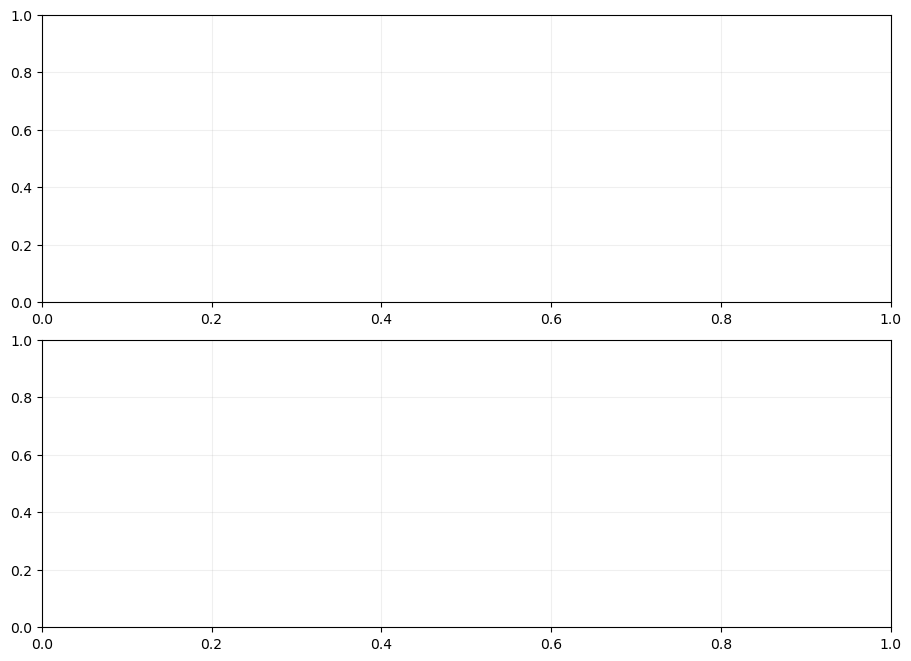

In [10]:
fig, axs = plt.subplots(nrows=2, ncols=1, sharey=False, figsize=(9,6.5), height_ratios=[1,1], constrained_layout=True)
axs = axs.flatten()

diffM = [np.log(np.mean(i)) for i in days_kz]
labels = [np.mean(i) for i in days_kz]
labels = ["%2.1e" % i for i in labels]

print(diffM)
for ax in axs: 
    ax.grid(alpha=0.2)

# Create norm 
maxh= 6

inds = [0, 1, 7, 9, 8, 11, 13, 15, 16, 19]
inds = [14, 18 ,19 ,10, 15, 11, 2, 7,  9, 13, 8, 11]

duration0 = [duration[i] for i in inds] 
days_mc0 = [days_mc[i] for i in inds] 
days_dm0 = [days_dm[i] for i in inds] 
days2plot0 = [days2plot[i] for i in inds] 
kappa0 = [days_kz[i] for i in inds]
norm = mpl.colors.Normalize(vmin=0, vmax=maxh) 
colors = [cmc.glasgow_r(i/maxh) for i in duration0]
lkappa0 = [np.log(np.mean(i)) for i in kappa0]
print(lkappa0)
# assert(False)
# c1 = [abs(i)/6 - 0.5 for i in diffM]
# colors = [cmc.glasgow_r(i) for i in c1]
# norm = mpl.colors.Normalize(vmin=0, vmax=max(diffM)) 


ticks = ["8/%d" % i for i in days2plot0]

# Colorbar
# h = axs[0].scatter([], [], vmin=0, vmax=1, cmap=cmc.hawaii)
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmc.glasgow_r), ax= axs[1], orientation='horizontal', label="DWL duration (hr)", shrink=0.4)
# colors = cmc.hawaii(np.linspace(0,1,len(days_dm)))


bplot = axs[0].bar(lkappa0, [np.mean(i) for i in days_mc0], 
                   width=0.05,
                   color=colors,
                   label=ticks) 

bplot = axs[1].bar(lkappa0, [np.mean(i) for i in days_dm0], 
                   width=0.05,
                   color=colors,
                   label=ticks) 

# bplot = axs[2].bar(lkappa0, [np.mean(i) for i in kappa0], 
#                    width=0.05,
#                    color=colors,
#                    label=ticks) 

# bplot = axs[2].boxplot(kappa0,
#                 patch_artist=True,  # fill with color
#                 tick_labels=ticks,
#                 positions=lkappa0, 
#                 showfliers=False, showmeans=True, zorder=2,
#                 meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)


                # tick_labels=ticks,
                # showfliers=False,
                # showmeans=True, 
                # zorder=2) #,
                # meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})

# bplot = axs[0].boxplot(days_mc0,
#                 patch_artist=True,  # fill with color
#                 tick_labels=ticks,
#                 positions=lkappa0, 
#                 showfliers=False,
#                 showmeans=True, 
#                 zorder=2,
#                 meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)

# bplot = axs[1].boxplot(days_dm0,
#                 patch_artist=True,  # fill with color
#                 tick_labels= ticks,
#                 showfliers=False,
#                 positions=lkappa0, 
#                 showmeans=True, 
#                 zorder=2,
#                 meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)

# bplot = axs[2].boxplot(kappa0,
#                 patch_artist=True,  # fill with color
#                 tick_labels=ticks,
#                 positions=lkappa0, 
#                 showfliers=False, showmeans=True, zorder=2,
#                 meanprops={"marker":"o","markerfacecolor":"black", "markeredgecolor":"white"})
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)

# axs[2].set_yscale('log')
axs[1].set_ylim(0, 0.6)
axs[0].set_ylim(0, 2) 

axs[0].set_title("(a) $Microcystis$")
axs[1].set_title("(b) Diatoms")
axs[1].set_ylim(0,)
axs[0].set_ylabel("Growth (1/day)")
axs[1].set_ylabel("Growth (1/day)")
# plt.tight_layout()
# fig.savefig("results2.png")


[16 13 17 11 18  9 19 12  8 14  5 15  7  3 10  6 20  2  0  4  1]


AssertionError: 

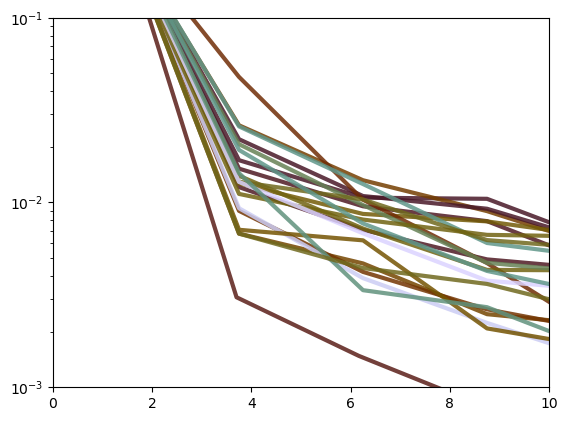

In [ ]:


fig2 = plt.figure()
ax = plt.gca()
# colors = [cmc.hawaii(i/22) for i in range(21)] 
colors = [cmc.glasgow_r(i/9) for i in duration]
inds = np.argsort(duration)
days_mc_s = [days_mc[i] for i in inds]
days_mc_s = [k[k>1e-8] for k in days_mc_s]

colors_s = [colors[i] for i in inds]

print(inds)

# ax.hist(days_mc_s, bins=500, density=True, alpha=0.5, stacked=True, color=colors_s)
# plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmc.glasgow_r), ax= ax, orientation='horizontal', label="DWL duration (hr)", shrink=0.4)
ax.set_xlim(0, 10)
# ax.set_ylim(0, 0.1)

for color,val in zip(colors, days_mc_s):
    hist, bins = np.histogram(val, bins=8, density=True)
    bin_centers = (bins[1:]+bins[:-1])*0.5
    ax.plot(bin_centers, hist,  color=color, alpha=0.85, linewidth=3)


ax.set_ylim(1e-3, 1e-1)
ax.set_yscale('log')
assert(False)

axs[2].hist(after_data, bins=20, density=True, alpha=0.5, stacked=True, color=colors)
after_data = np.concatenate(after_data)
hist, bins = np.histogram(after_data, bins=15, density=True)
bin_centers = (bins[1:]+bins[:-1])*0.5
axs[2].plot(bin_centers, hist, '-k', alpha=0.5)


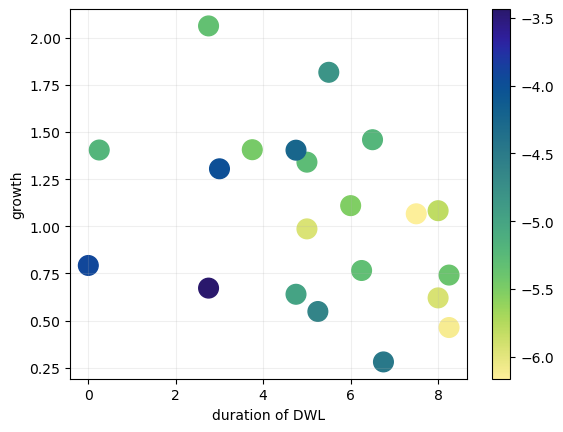

In [ ]:
# New figure for the discussion


# fig, axs = plt.subplots(nrows=3, ncols=1, sharey=False, figsize=(10,7.5), height_ratios=[1,1,1.2], constrained_layout=True)
# axs = axs.flatten()
fig = plt.figure()
ax = plt.gca() 


average_diff = [np.mean(i) for i in days_kz]
average_mc = [np.mean(i) for i in days_mc]
average_dm = [np.mean(i) for i in days_dm]
sorted_by_diff = np.argsort(average_diff)
days_sorted = days2plot[sorted_by_diff]

# h= ax.scatter(average_diff, ending, s=100, c=average_dm, cmap=cmo.cm.thermal_r)
total = np.array(average_mc) + np.array(average_dm)

h= ax.scatter(duration, total, s=200, c=np.log(average_diff), cmap=cmo.cm.haline_r)
plt.colorbar(h)
ax.set_xlabel("duration of DWL")
ax.set_ylabel("growth")
# ax.plot([0, 1], [0,1], '--k')
# print(sorted_by_diff)


# ax.set_xscale("log")
# ax.set_yscale("log")
# for i,d in enumerate(days2plot):

#     ds = guess["%02d" % (d)]
#     time = Dates[ds.t.values]

#     g1= ds.gamma1.sum(dim='z')
#     g1 = g1.argmax(dim='t')
#     print(g1.values)
#     time_of_max = Dates[ds.t.values[0] + g1.values]
#     time_of_max = time_of_max.hour

#     ax.plot(time_of_max, ending[i], 'o')
#     # g1 = np.clip(g1,1e-7, 10)
    # g1 = g1[g1<10] 
    # days_mc.append(g1)
    # # 
    # g2 = ds.gamma2.values.ravel()  * (86400)  
    # g2 = g2[g2<10] 
    # days_dm.append(g2)

    # hydro0 = hydro.isel(time=ds.t.values)
    # # hydro0 = hydro0.isel(time=np.arange(3122, 5122))
    # d1 = hydro0['Kz'].values.ravel()
    # days_kz.append(d1)


ax.grid(alpha=0.2)


In [15]:

duration = []
ending = [] 
for i,d in enumerate(days2plot):

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    X, averaged_md, mask = get_dwl(d, time, 1)
    if sum(mask)>2:
        duration0 = (X[mask][-3] - X[mask][0])/np.timedelta64(1, 's')
        hours = duration0/3600
        # print(hours)
        duration.append(hours)
        ending.append(X[mask][-3])
    else:
        duration.append(0)
        ending.append(np.nan)

print(min(duration))
print(max(duration))


ending = [pd.to_datetime(i).hour + pd.to_datetime(i).minute/60 for i in ending]
print(ending)

0
8.0
[17.5, 15.75, 17.0, 15.75, 16.0, 14.0, 14.75, 14.25, 13.5, 15.0, 14.5, 15.0, 15.5, nan, 15.25, 15.0, nan, 12.5, 13.5, 13.25, 15.0]


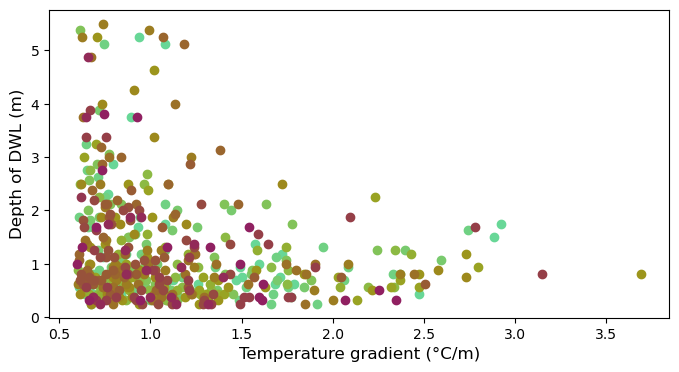

In [ ]:
fig = plt.figure(figsize=(8,4))
ax = plt.gca()
ax.set_xlabel("Temperature gradient (°C/m)", fontsize=12)
ax.set_ylabel("Depth of DWL (m)", fontsize=12)

for i,d in enumerate(range(6,25)):
    color = cmc.hawaii_r(d/26)
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    X, averaged_md, mask = get_dwl(d, time, 0.9)


    temp0 = temp.loc[temp.day == d]
    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])
    maxs = np.nanmax(dT, axis=0)
    kernel2 = np.ones(4)/4
    averaged_md = np.convolve(md, kernel2, mode='same')

    ax.plot(maxs[maxs>0.6], averaged_md[maxs>0.6], 'o', color=color)
    # assert(False)
    # mask = maxs>T0
    # mask = mask & (X > time[0]) # Crop to daytime hours
    # mask = mask & (X < time[-1])
    # if sum(mask)>2:
    #     difference = (pd.to_datetime(X[mask][-1]) - pd.to_datetime(X[mask][-2])) 
    #     if difference  > pd.Timedelta(hours=1):
    #         print("Warning: gap in DWL detection larger than 1 hour on day %d" % day)
    #         mask[np.where(X==X[mask][-1])[0][0]] = False
    # print(averaged_md)
    # assert(False)
    # if sum(mask)>2:
    #     duration0 = (X[mask][-3] - X[mask][0])/np.timedelta64(1, 's')
    #     hours = duration0/3600
    #     # print(hours)
    #     duration.append(hours)
    # else:
    #     duration.append(0)
# ax.set_yscale('log')
# ax.set_xscale('log')


In [ ]:

# fig, axs = plt.subplots(figsize=(10,6), nrows=3, ncols=1, sharex=False) 
# axs = axs.flatten()

# # bplot = axs[0].boxplot(days_kz,
# #                 patch_artist=True,  # fill with color
# #                 tick_labels=days2plot,
# #                 showfliers=False, showmeans=True)
# axs[0].set_yscale("log")


# # axs[0].violinplot(days_kz,
# #                   showmeans=False,
# #                   showmedians=True,
# #                   positions=days2plot)


# # print(days2plot.astype(int))
# # v = [np.mean(i) for i in days_kz]
# # axs[1].plot(days2plot, v, '-o')
# # axs[1].set_title("mean of $K_z$")

# axs[2].violinplot(days_dm,
#                   showmeans=False,
#                   showmedians=True,
#                   positions=days2plot)


# axs[1].violinplot(days_mc,
#                   showmeans=False,
#                   showmedians=True,
#                   positions=days2plot)
# # axs[1].boxplot(days_dm,
# #                 patch_artist=False,  # fill with color
# #                 tick_labels=days2plot,
# #                 showfliers=False,
# #                 showmeans=True, notch=False)



# # axs[1].boxplot(days_mc,
# #                 patch_artist=True,  # fill with color
# #                 tick_labels=days2plot,
# #                 showfliers=False,
# #                 showmeans=True, notch=False)



# # v = [np.sum(i) for i in days_mc]
# # axs[1].plot(days2plot, v, '-o')
# axs[1].set_title("sum of $Microcystsis$")

# # v = [np.sum(i) for i in days_dm]
# # axs[1].plot(days2plot, v, '-o')
# axs[2].set_title("sum of $diatoms$")

# for ax in axs:
#     ax.grid(alpha=0.3)

# axs[1].set_xticks(days2plot)
# axs[2].set_xticks(days2plot)

# axs[0].set_yscale("log")
# axs[1].set_yscale("log")
# axs[2].set_yscale("log")
# plt.tight_layout()

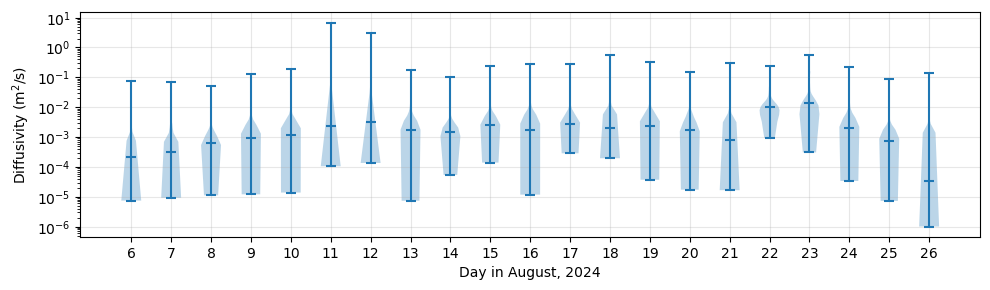

In [ ]:
# Violin plot of diffusivity 

# fig = plt.figure(figsize=(10,3)) 
# ax = plt.gca()


# ax.set_yscale("log")


# ax.violinplot(days_kz,
#                   showmeans=False,
#                   showmedians=True,
#                   positions=days2plot)

# for pc, color in zip(plots['bodies'], colors):
#     pc.set_facecolor(color)




# ax.grid(alpha=0.3)
# ax.set_ylabel("Diffusivity (m$^2$/s)")
# ax.set_xticks(days2plot)
# ax.set_xlabel("Day in August, 2024")
# plt.tight_layout()
# fig.savefig("diffusivity_range.png")

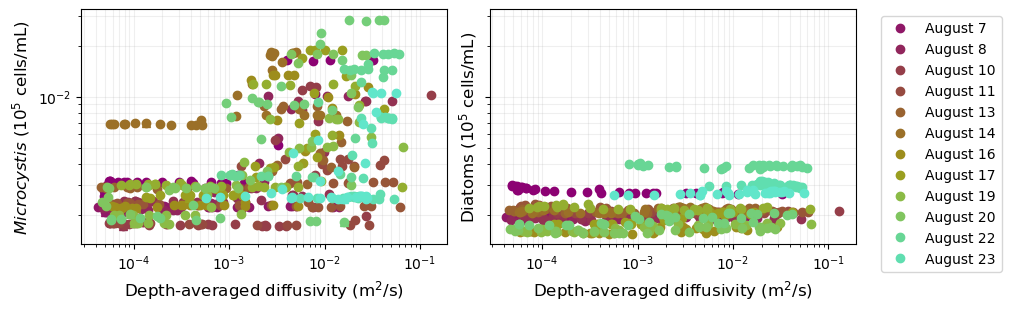

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 3), sharex=True, sharey=True, constrained_layout=True)

# range(6,28,1)
for i,d in enumerate(range(6, 25)):
    try:
        ds = guess["%02d" % (d)]
    except:
        continue
    if d == 15 :
        continue
    time = Dates[ds.t.values]

    hydro0 = hydro.isel(time=ds.t.values)
    kz = hydro0['Kz'].max(dim="z") - hydro0['Kz'].min(dim="z")
    kz = hydro0['Kz'].mean(dim="z")

    mc      = ds['algae1'].mean(dim="z") #* 86400
    mc[mc<0] = np.nan
    diatom = ds['algae2'].mean(dim="z")
    c = cmc.hawaii((d-6)/21)
    axs[0].plot(kz[0], mc[0], '^', color=c, linewidth=3) 
    axs[1].plot(kz[0], diatom[-1], 'x', color=c, linewidth=3) 

    if i%3 == 0:
        axs[0].plot(kz[::200], mc[::200], 'o', color=c, linewidth=3) 
        axs[1].plot(kz[::200], diatom.values[::200], 'o', color=c, linewidth=3)
    else:
        axs[0].plot(kz[::200], mc[::200], 'o', color=c, linewidth=3, label="August %d" % d) 
        axs[1].plot(kz[::200], diatom.values[::200], 'o', color=c, linewidth=3, label="August %d" % d) 

        # ax.plot
    # axs[i].grid(alpha=0.2)

# ax.plot([0, 1.5], [0, 1.5], 'k--', alpha=0.5)
axs[0].set_ylabel("$Microcystis$ (10$^5$ cells/mL)", fontsize=12)
axs[1].set_ylabel("Diatoms (10$^5$ cells/mL)", fontsize=12)
for ax in axs:
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel("Depth-averaged diffusivity (m$^2$/s)", fontsize=12)
    # ax.set_ylim(1e-3, .05)
    ax.grid(alpha=0.2, which='both')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
fig.savefig("mc_diatom_scatter.png", dpi=300, bbox_inches='tight')


/tmp/ipykernel_1956721/3542145384.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)


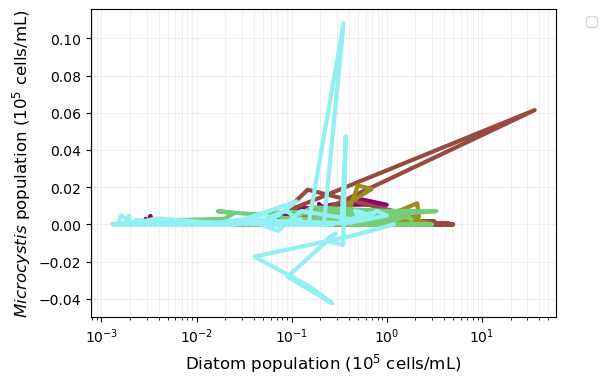

In [ ]:
# # characterize growth at depths 


# fig2 = plt.figure(figsize=(6, 4))
# ax2 = fig2.add_subplot(111)


# STEP = 0.25
# zs = np.arange(0, 4, step=STEP)


# for i,d in enumerate(SSCM):
#     ds = guess["%02d" % (d)]
#     time = Dates[ds.t.values]
#     t0 = [t.hour + t.minute/60 for t in time]
#     hydro0 = hydro.isel(time=ds.t.values)
#     # axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 

#     tmax = [] 
#     zavg = [] 
#     growth= [] 

#     for ia, zmax in enumerate(zs):
#         zmin = zmax + STEP 
        
#         growth0 = ds.gamma1.sel(z=slice(zmin, zmax)).mean(dim='z') *(86400)
#         max0 = np.argmax(growth0.values)
#         g = growth0[max0].values
#         if g<0:
#             growth.append(0) 
#         else:
#             growth.append(g) # growth0[max0].values)
        
#         tmax.append(t0[max0])
#         zavg.append(-zmax)

#     ax2.plot(tmax, zavg, color=cmo.cm.haline_r(i/13), alpha=0.8)    
#     ax2.scatter(tmax, zavg, s=growth,  color=cmo.cm.haline_r(i/13), label="08/%d" % (d))    

# ax2.grid(alpha=0.3)
# ax2.set_ylabel("Depth (m)")
# ax2.set_xlabel("Hour of max growth (hours)")
# ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)


# # 

In [ ]:
# # Depth of max growth
# fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(12, 14), sharex=True, sharey=True)
# axs = axs.flatten()


# for i,d in enumerate(range(6,27)):
#     ds = guess["%02d" % (d)]
#     time = Dates[ds.t.values]
#     t0 = [t.hour + t.minute/60 for t in time]
#     growth0 = ds.gamma1.argmax(dim="z")
#     depths = ds.gamma1.z.values[growth0]
#     depths[depths==5.95] = np.nan


#     hydro0 = hydro.isel(time=ds.t.values)
#     h= axs[i].contourf(t0, -z, hydro0.Kz.values.T, cmap=cmo.cm.haline_r, levels=[1e-7,1e-6,1e-5,1e-4, 1e-3,  1e-2,1e-1], norm=norm, alpha=0.9) 
#     axs[i].plot(t0, -depths,'.', color='white') #cmo.cm.haline_r(i/20))

#     ax2.plot(t0, -depths,'-', color=cmc.bamako(i/20), label="08/%d" % (d))
#     axs[i].set_title("August %d" % d)
#     axs[i].grid(alpha=0.3)
# plt.colorbar(h)
# axs[i].set_ylim(-5.5, 0)
# axs[i].set_xlim(7, 20)

# # 

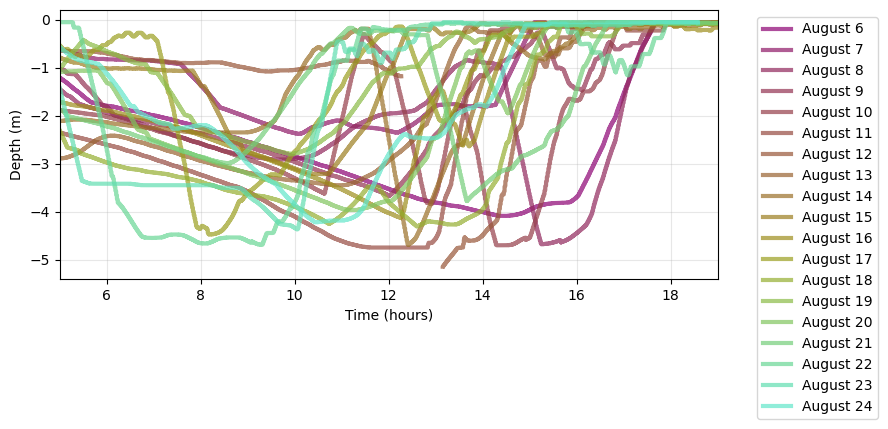

In [ ]:
# Depth of max growth

fig2 = plt.figure(figsize=(9, 4))
ax2 = fig2.add_subplot(111)

NK = 300 
conv = np.ones(NK)/NK

days0 = list(range(6, 27, 1)) 
for i,d in enumerate(days2plot) : #interesting_days):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]

    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    averaged_depth = np.convolve(depths, conv, mode='same')
    ax2.plot(t0, -averaged_depth,'-',  color=cmc.hawaii(i/len(days0)),  
                linewidth=3, alpha=0.7, label ="August %d" % (d))

ax2.grid(alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
ax2.set_xlim(5, 19)
ax2.set_ylabel("Depth (m)")
ax2.set_xlabel("Time (hours)")
plt.tight_layout()
# fig2.savefig("plots/depth_of_max_growth_and_mixed_layer2.png", dpi=300)
# 

KeyError: '25'

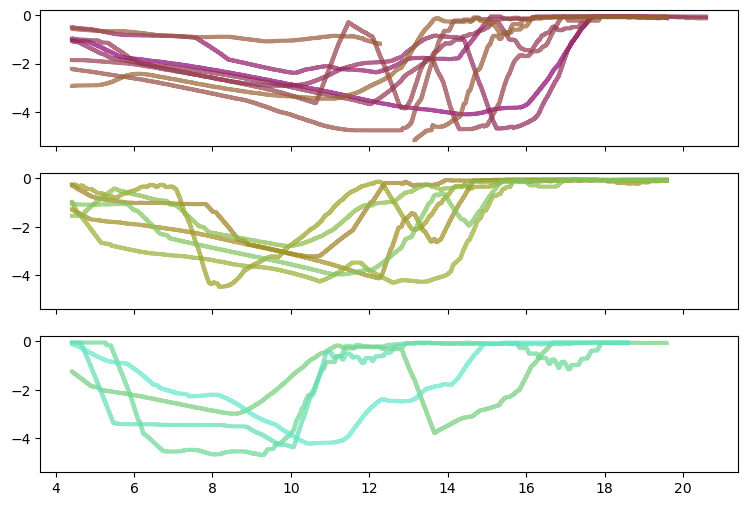

In [ ]:
# Depth of max growth

fig2, axs = plt.subplots(figsize=(9, 6), nrows=3, ncols=1, sharex=True, sharey=True)
axs = axs.flatten()
NK = 300 
conv = np.ones(NK)/NK

ax2 = axs[0]
days0 = list(range(6, 14, 1)) 
for i,d in enumerate(days0) : #interesting_days):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]

    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    averaged_depth = np.convolve(depths, conv, mode='same')
    ax2.plot(t0, -averaged_depth,'-',  color=cmc.hawaii(i/21),  
                linewidth=3, alpha=0.7, label ="August %d" % (d))

ax2 = axs[1]
days0 = list(range(15, 21, 1)) 
for i,d in enumerate(days0) : #interesting_days):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]

    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    averaged_depth = np.convolve(depths, conv, mode='same')
    ax2.plot(t0, -averaged_depth,'-',  color=cmc.hawaii((i+9)/21),  
                linewidth=3, alpha=0.7, label ="August %d" % (d))
     
ax2 = axs[2]
days0 = list(range(21, 27, 1)) 
for i,d in enumerate(days0) : #interesting_days):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]

    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    averaged_depth = np.convolve(depths, conv, mode='same')
    ax2.plot(t0, -averaged_depth,'-',  color=cmc.hawaii((i+15)/21),  
                linewidth=3, alpha=0.7, label ="August %d" % (d))

for ax2 in axs:
    ax2.grid(alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
    ax2.set_xlim(6, 19)
    ax2.set_ylabel("Depth (m)")
    

axs[-1].set_xlabel("Time (hours)")
plt.tight_layout()
# fig2.savefig("plots/depth_of_max_growth_and_mixed_layer2.png", dpi=300)
# 

KeyError: '25'

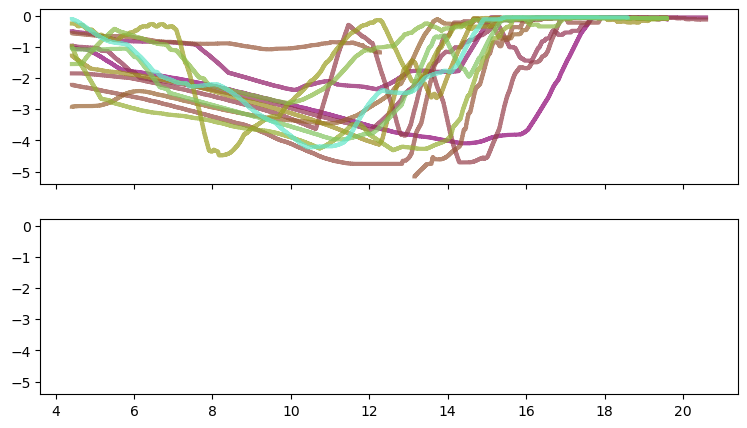

In [ ]:
# Depth of max growth

def day2color(d):
    return cmc.hawaii((d-6)/21)

fig2, axs = plt.subplots(figsize=(9, 5), nrows=2, ncols=1, sharex=True, sharey=True)
axs = axs.flatten()
NK = 300 
conv = np.ones(NK)/NK

days1 = [6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20,  24, 25, 26]
days2 = [15, 14, 23, 21, 22, 8,]


ax2 = axs[0]
for i,d in enumerate(days1) : #interesting_days):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]

    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    averaged_depth = np.convolve(depths, conv, mode='same')
    ax2.plot(t0, -averaged_depth,'-',  color=day2color(d),  
                linewidth=3, alpha=0.7, label ="August %d" % (d))

ax2 = axs[1]

for i,d in enumerate(days2) : #interesting_days):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]

    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    averaged_depth = np.convolve(depths, conv, mode='same')
    ax2.plot(t0, -averaged_depth,'-',  color=day2color(d),  
                linewidth=3, alpha=0.7, label ="August %d" % (d))

axs[0].fill_betweenx([-5, 0], 8, 14.2, color='gray', alpha=0.2, label="Sub-surface \nChl-a growth maxima")

for ax2 in axs:
    ax2.grid(alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    ax2.set_xlim(6, 19)
    ax2.set_ylabel("Depth (m)")
    ax2.set_ylim(-5, 0)
    

axs[-1].set_xlabel("Time (hours)")
plt.tight_layout()
fig2.savefig("plots/depth_of_max_growth_and_mixed_layer_split.png", dpi=300)
# 

0
1
2
3
4
5


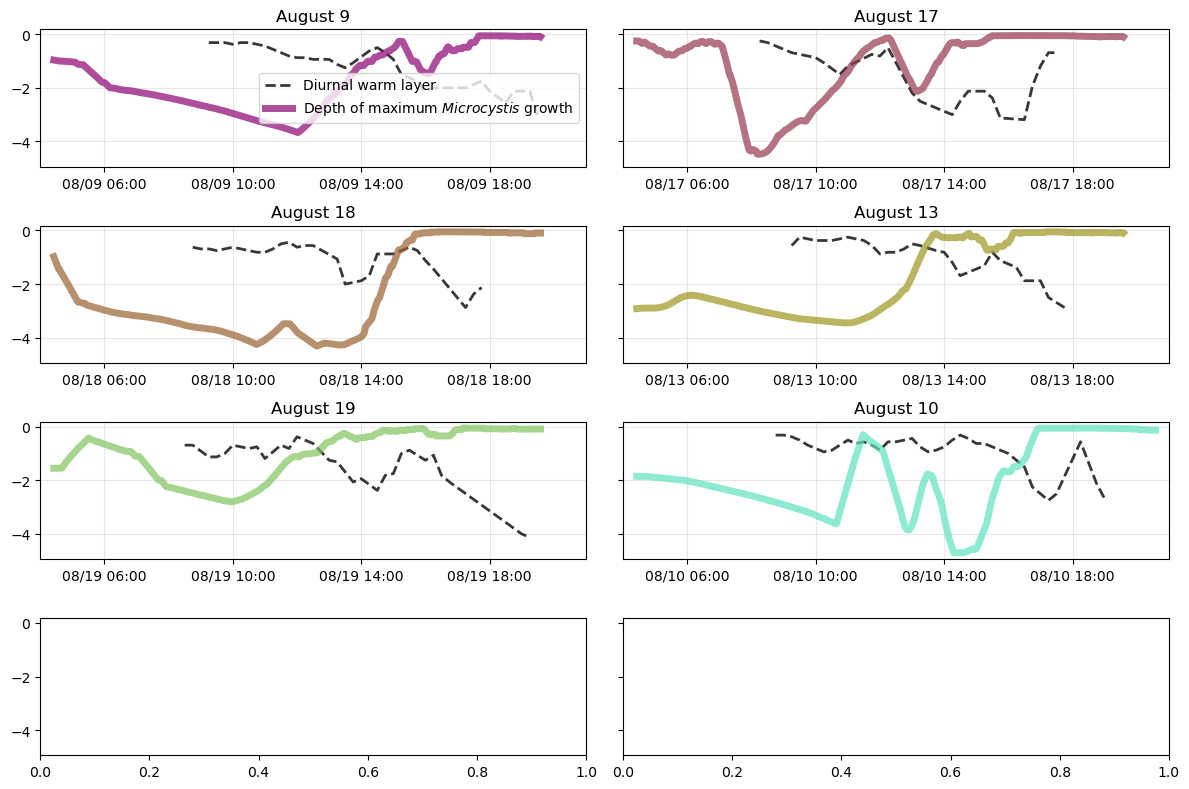

In [ ]:
# Depth of max growth

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(12, 8), sharex=False, sharey=True)
axs = axs.flatten()
NK = 300 
conv = np.ones(NK)/NK


# interesting_days = [8, 9, 12, 15, 17, 19, 21, 26]
for i,d in enumerate(days2plot):
    print(i)

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan
    x, mixed_d, mask = get_dwl(d, time, 0.5)

    axs[i].plot(x[mask], -mixed_d[mask], '--',   color="k" , linewidth=2, alpha=0.78, label="Diurnal warm layer")

    averaged_depth = np.convolve(depths, conv, mode='same')
    axs[i].plot(time, -averaged_depth,'-', 
                color=cmc.hawaii(i/len(days2plot)),  
                linewidth=5, alpha=0.7, label ="Depth of maximum $Microcystis$ growth")

    axs[i].set_xlim(time[0], time[-1])
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    axs[i].grid(alpha=0.3)
axs[0].legend()
plt.tight_layout()
fig.savefig("plots/depth_of_max_growth_and_mixed_layer.png", dpi=300)

<>:51: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_771530/2949418485.py:51: SyntaxWarning: invalid escape sequence '\m'
  axs[-1].set_xlabel("Chlorophyll-a ($\mu$g/L)")


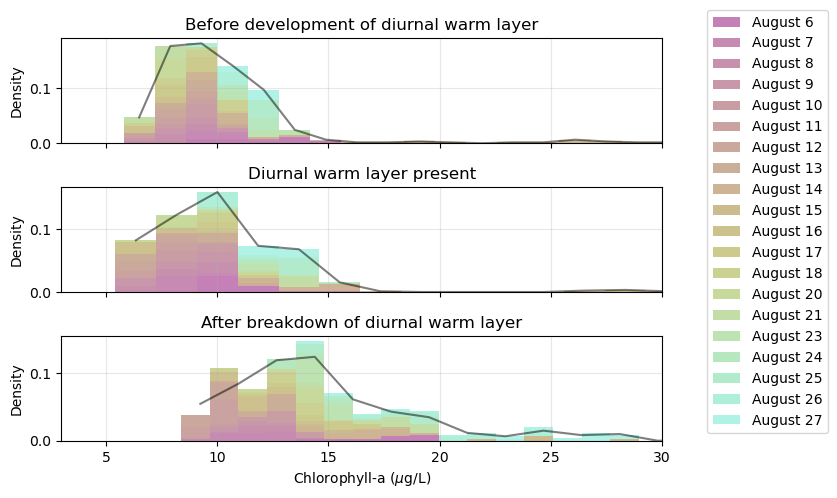

In [ ]:
# histogram of chl-a sorted by time 

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(7, 5), sharex=True, sharey=False) #, height_ratios=[1, 1.2])
axs = axs.flatten()

obs_chla = obs_roll*1e-3

before_data = [] 
during_data = []
after_data = []
colors = [cmc.hawaii(i/22) for i in range(20)] 
labels = []

for i,d in enumerate(range(6,28)):

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    X, averaged_md, mask = get_dwl(d, time, 1.0)
    if sum(mask)>2:
        before = (chla.time>time[0]) & (chla.time<X[mask][0])
        during = (chla.time>X[mask][0]) & (chla.time<X[mask][-1])
        after = (chla.time>X[mask][-1]) & (chla.time<time[-1])
        before_data.append(obs_chla[before].values[:])
        during_data.append(obs_chla[during].values[:])
        after_data.append(obs_chla[after].values[:])
        labels.append("August %d" % d)

axs[0].hist(before_data, bins=20, density=True, alpha=0.5, stacked=True, color=colors, label=labels)
before_data = np.concatenate(before_data)
hist, bins = np.histogram(before_data, bins=20, density=True)
bin_centers = (bins[1:]+bins[:-1])*0.5
axs[0].plot(bin_centers, hist, '-k', alpha=0.5)

axs[1].hist(during_data, bins=20, density=True, alpha=0.5, stacked=True, color=colors)
during_data = np.concatenate(during_data)
hist, bins = np.histogram(during_data, bins=20, density=True)
bin_centers = (bins[1:]+bins[:-1])*0.5
axs[1].plot(bin_centers, hist, '-k', alpha=0.5)

axs[2].hist(after_data, bins=20, density=True, alpha=0.5, stacked=True, color=colors)
after_data = np.concatenate(after_data)
hist, bins = np.histogram(after_data, bins=15, density=True)
bin_centers = (bins[1:]+bins[:-1])*0.5
axs[2].plot(bin_centers, hist, '-k', alpha=0.5)

for ax in axs:
    ax.set_xlim(3,30)
    ax.grid(alpha=0.3)
    ax.set_ylabel("Density")
axs[-1].set_xlabel("Chlorophyll-a ($\mu$g/L)")
fig.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1)
axs[0].set_title("Before development of diurnal warm layer")
axs[1].set_title("Diurnal warm layer present")
axs[2].set_title("After breakdown of diurnal warm layer")


plt.tight_layout()  
fig.savefig("plots/histogram.png", dpi=300)

In [ ]:


obs_chla = obs_roll*1e-3

before_data = [] 
during_data = []
after_data = []
colors = [cmc.hawaii(i/22) for i in range(20)] 
labels = []

for i,d in enumerate(range(6,28)):

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    X, averaged_md, mask = get_dwl(d, time, 1.0)
    if sum(mask)>2:
        before = (chla.time>time[0]) & (chla.time<X[mask][0])
        during = (chla.time>X[mask][0]) & (chla.time<X[mask][-1])
        after = (chla.time>X[mask][-1]) & (chla.time<time[-1])
        before_data.append(obs_chla[before].values[:])
        during_data.append(obs_chla[during].values[:])
        after_data.append(obs_chla[after].values[:])
        labels.append("August %d" % d)

before_data = np.concatenate(before_data)
during_data = np.concatenate(during_data)
after_data = np.concatenate(after_data) 



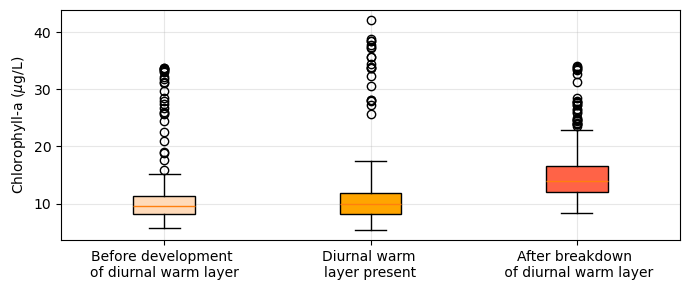

In [ ]:

# Box and whiskers plot
fig = plt.figure(figsize=(7, 3))
ax = plt.gca() 

bplot = ax.boxplot([before_data, during_data, after_data],
                   patch_artist=True,  # fill with color
                   tick_labels=["Before development \nof diurnal warm layer", "Diurnal warm \nlayer present", 
                                "After breakdown \n of diurnal warm layer"])  # will be used to label x-ticks


colors = ['peachpuff', 'orange', 'tomato']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.grid(alpha=0.3)
ax.set_ylabel(r"Chlorophyll-a ($\mu$g/L)")
plt.tight_layout()  
fig.savefig("plots/box_plot.png", dpi=300)

In [ ]:
# Depth of max growth
assert(False)
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(12, 13), sharex=False, sharey=True)
axs = axs.flatten()
NK = 300 
conv = np.ones(NK)/NK


fig2 = plt.figure(figsize=(9, 4))
ax2 = fig2.add_subplot(111)

interesting_days = list(range(6, 26))
# interesting_days = [8, 9, 12, 15, 17, 19, 21, 26]
interesting_days = [6, 8, 9, 12, 15, 17, 19, 21, 22, 26]

for i,d in enumerate(interesting_days):
    print(i)
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    X, averaged_md, mask = get_dwl(d, time, 1)
    axs[i].plot(X[mask], -averaged_md[mask], '--',   color="k" , linewidth=2, alpha=0.78, label="Diurnal warm layer")

    averaged_depth = np.convolve(depths, conv, mode='same')
    axs[i].plot(time, -averaged_depth,'-', 
                color=cmc.hawaii(i/len(interesting_days)),  
                linewidth=5, alpha=0.7, label ="Depth of maximum $Microcystis$ growth")

    # ax2 = axs[i].twinx()
    # ax2.plot(chla.time, chla.obs_roll*1e-3, '-', color='#B4CF66', linewidth=2)
    # ax2.set_xlim(time[0], time[-1])
    # ax2.set_ylim(0,25)

    axs[i].hlines(-1, time[0], time[-1], colors='grey', alpha=0.15, linewidth=7)

    # print(depths)
    axs[i].set_xlim(time[0], time[-1])
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    # ax2.plot(t0, -depths,'-', color=cmc.bamako(i/20), label="August/%d" % (d))
    # axs[i].set_title("August %d" % d)
    axs[i].grid(alpha=0.3)
axs[0].legend()
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
# fig.savefig("plots/depth_of_max_growth_and_mixed_layer.png", dpi=300)

AssertionError: 

0 days 01:15:00
0 days 01:45:00
0 days 00:15:00
0 days 02:00:00
0 days 01:15:00
0 days 01:15:00
0 days 00:45:00
0 days 00:30:00
0 days 01:00:00
0 days 01:00:00
0 days 00:15:00
0 days 00:30:00


/tmp/ipykernel_1922640/1027432969.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_1922640/1027432969.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 0, 'Day in August')

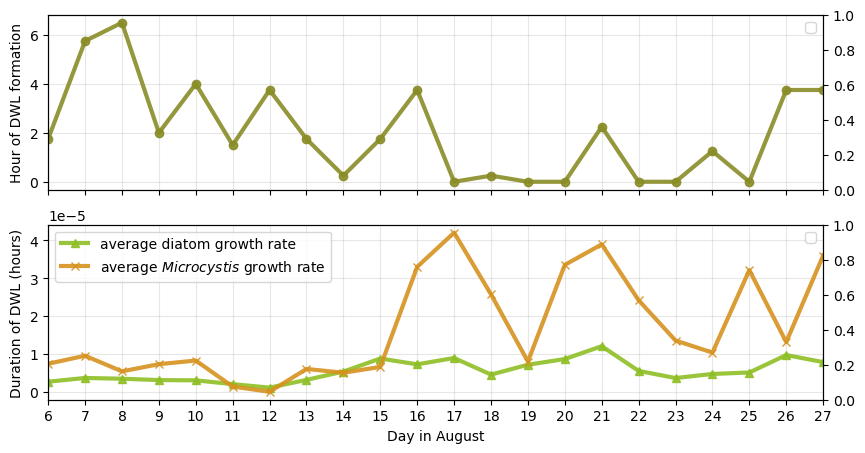

In [ ]:
# Time DWL starts developing

# fig = plt.figure(figsize=(9, 4))
# ax = fig.add_subplot(111)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=True, sharey=False)
axs = axs.flatten()

interesting_days = [6, 8, 9, 12, 15, 17, 19, 21, 22, 26]
total_days = range(6, 28)

start_hour = [] 
duration = [] 
m1g = [] 
d1g = []
ax2 = axs[0].twinx()
ax3 = axs[1].twinx()
for i,d in enumerate(total_days):
    # print(d)
    ds = guess["%02d" % (d)]
    m0 = np.mean(ds.gamma1.values.flatten())
    d0 = np.mean(ds.gamma2.values.flatten()) 
    time = Dates[ds.t.values]

    hydro0 = hydro.isel(time=ds.t.values)
    kz = np.mean(hydro0.Kz.values.flatten()) 
    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    d1g.append(d0)
    m1g.append(m0)


    x, mixed_d, mask = get_dwl(d, time, 1.8)
    x0 = pd.to_datetime(x[mask])
    try:
        start = x0[0].hour  + x0[0].minute/60
        hour = start_hour.append(start)
        breakdown = x0[-1].hour  + x0[-1].minute/60
        # print(breakdown)
        breakdown = breakdown - start
        # print(pd.to_datetime(x[mask][-1]).hour)
        # if breakdown > 20:
        #     breakdown = 20
        duration.append(breakdown)
    except:
        start_hour.append(np.nan)
        duration.append(0)

# ax3.plot(d, kz, 'o', color=cmo.cm.haline_r(i/20))
axs[1].plot(total_days, d1g, '-^', color='#8FBF26', label="average diatom growth rate", linewidth=3, alpha=0.9)
axs[1].plot(total_days, m1g, '-x', color='#D69220', label="average $Microcystis$ growth rate", linewidth=3, alpha=0.9)
    
# axs[0].plot(total_days, start_hour, '-o', color="#559BD9", linewidth=3, alpha=0.9)
axs[0].plot(total_days, duration, '-o', color="#898C26", linewidth=3, alpha=0.9)
ax3.legend()
axs[0].set_ylabel("Hour of DWL formation")
axs[0].xaxis.set_ticks(total_days)
axs[0].set_xlim(6, 27)

# axs[1].set_ylim(0, 15)
# ax3.set_yscale('log')

axs[0].set_ylabel("Hour of DWL formation")
axs[1].set_ylabel("Duration of DWL (hours)")
for ax in axs:
    ax.grid(alpha=0.3)
    ax.legend()

axs[1].set_xlabel("Day in August")


TypeError: get_dwl() missing 1 required positional argument: 'T0'

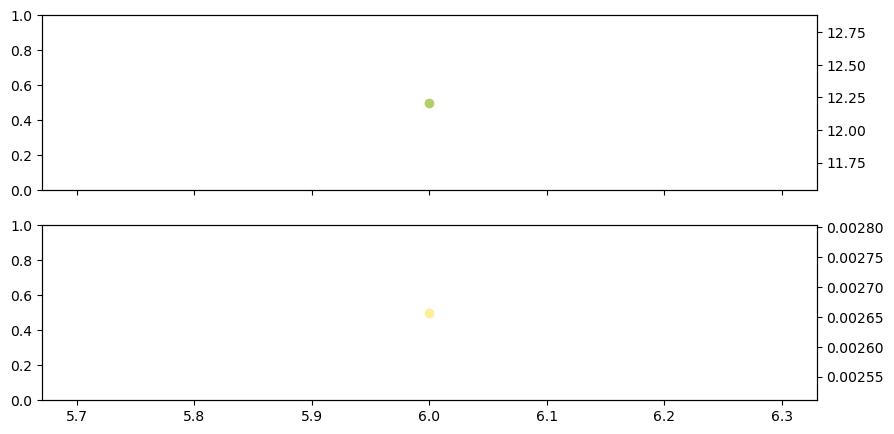

In [ ]:
# Time DWL starts developing

# fig = plt.figure(figsize=(9, 4))
# ax = fig.add_subplot(111)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=True, sharey=False)
axs = axs.flatten()

interesting_days = [6, 8, 9, 12, 15, 17, 19, 21, 22, 26]
total_days = range(6, 28)

depth = [] 
ax2 = axs[0].twinx()
ax3 = axs[1].twinx()
for i,d in enumerate(total_days):
    # print(d)
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    hydro0 = hydro.isel(time=ds.t.values)
    kz = np.mean(hydro0.Kz.values.flatten()) 
    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan

    chla0 = chla.loc[chla.day == d].iloc[20:90]
    chla_mean = np.nanmean(chla0.obs_roll.values * 1e-3 )
    ax2.plot(d, chla_mean, '-o', color='#B4CF66')
    ax3.plot(d, kz, '-o', color=cmo.cm.haline_r(i/20))
    x, mixed_d, mask = get_dwl(day, time)
    m0 = np.mean(mixed_d[mask]) 
    depth.append(m0)
    # axs[0].plot(d, sum(mixed_d[mask]<2.5), 'o', color="k")

axs[0].plot(total_days, depth, '-o', color="k")
axs[0].xaxis.set_ticks(total_days)
axs[0].set_xlim(6, 27)

for ax in axs:
    ax.grid(alpha=0.3)



       VALUE                time  chla_smoothed  model_time  pg_chla_perML  \
308   9620.0 2024-08-09 05:00:00         9806.0       27720         9620.0   
309  10330.0 2024-08-09 05:15:00        10163.0       27810        10330.0   
310  11940.0 2024-08-09 05:30:00        10142.0       27900        11940.0   
311   9050.0 2024-08-09 05:45:00        10084.0       27990         9050.0   
312  11600.0 2024-08-09 06:00:00        10004.0       28080        11600.0   
..       ...                 ...            ...         ...            ...   
373   7800.0 2024-08-09 21:15:00         8840.0       33570         7800.0   
374   8930.0 2024-08-09 21:30:00         8444.0       33660         8930.0   
375   8370.0 2024-08-09 21:45:00         8632.0       33750         8370.0   
376   6660.0 2024-08-09 22:00:00         8776.0       33840         6660.0   
377   6890.0 2024-08-09 22:15:00         9372.0       33930         6890.0   

     obs_roll  day  
308    9806.0    9  
309   10163.0    9  


NameError: name 'start_hour' is not defined

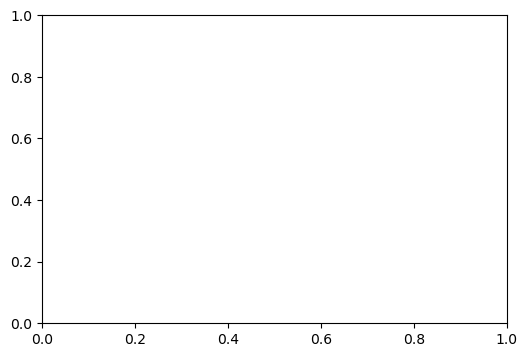

In [ ]:

fig = plt.figure(figsize=(6,4)) #(nrows=1, ncols=1, figsize=(10, 5), sharex=False, sharey=True)
ax = plt.gca() 


for i,d in enumerate(days2plot):
    ds = guess["%02d" % (d)]

    chla0 = chla.loc[chla.day == d].iloc[20:90]
    print(chla0)

    chla_mean = np.nanmean(chla0.obs_roll.values * 1e-3 )

    time = Dates[ds.t.values]
    ax.plot(start_hour[i], chla_mean, 'o', color=cmc.hawaii(i/20), markersize=10, alpha=0.7, label="08/%d" % (d))

ax.set_xlabel("Hour of DWL formation")
ax.set_ylabel("Mean near-surface Chlorophyll-a (ug/L)")
# ax.set_xlim(7, 13)
ax.grid(alpha=0.2)
# ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

-900000000000 nanoseconds
-900000000000 nanoseconds
-4500000000000 nanoseconds
-3600000000000 nanoseconds
-14400000000000 nanoseconds
-900000000000 nanoseconds


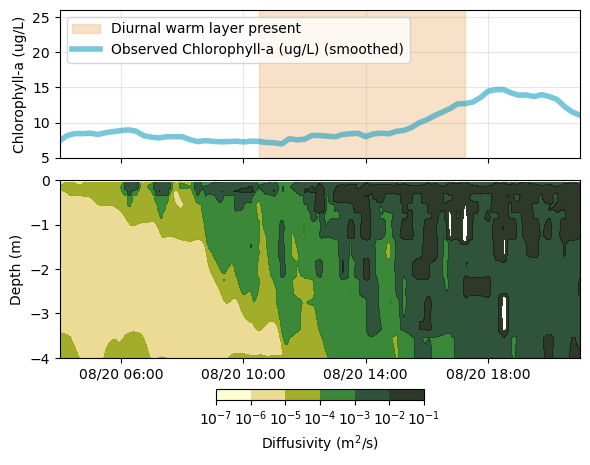

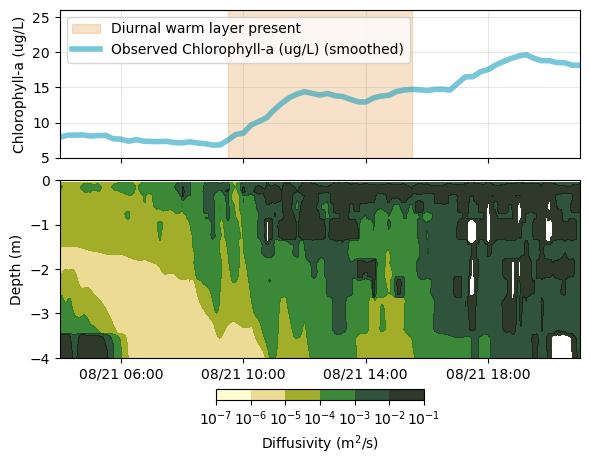

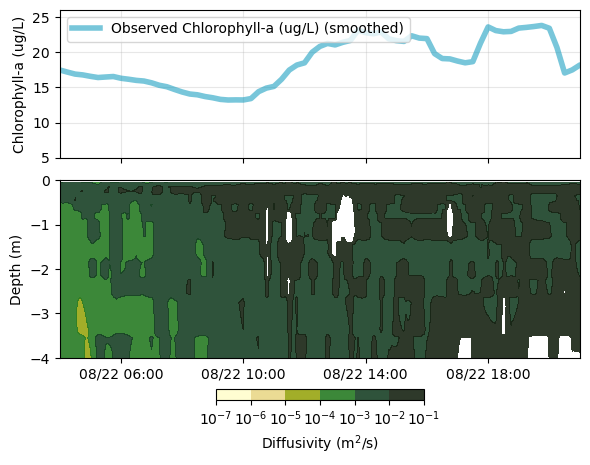

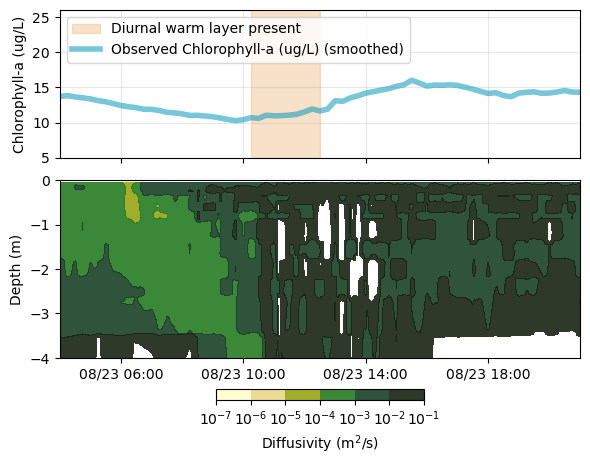

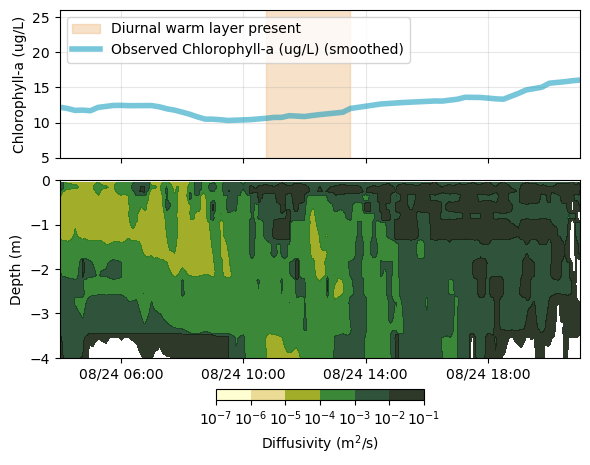

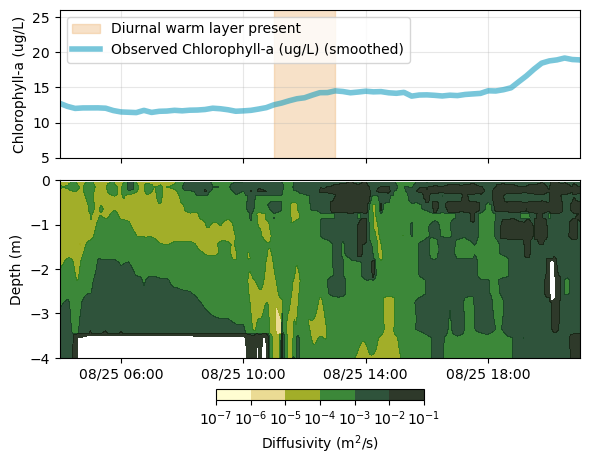

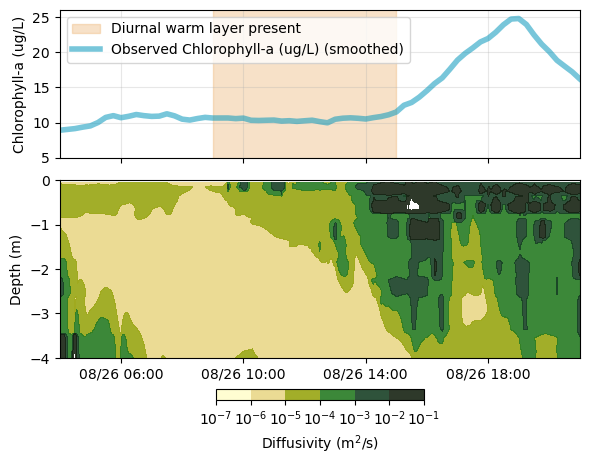

In [ ]:


import matplotlib as mpl 
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)
for i,d in enumerate(range(20,27)):

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True, sharey=False, height_ratios=[1, 1.2])
    axs = axs.flatten()

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    X, averaged_md, mask = get_dwl(d, time, 1.2)
    if sum(mask)>2:
        axs[0].fill_betweenx([-10, 50],X[mask][0], X[mask][-2], color="#EDB476", alpha=0.4, label="Diurnal warm layer present")
        # print(X[mask])
    # axs[0].plot(chla.time, obs*1e-3, color="#0998BC", alpha=0.15, linewidth=4, label='Observed Chlorophyll-a (ug/L)')
    # dchla = np.gradient(obs_roll.values*1e-3)
    # print(dchla)
    axs[0].plot(chla.time, obs_roll.values*1e-3, color="#0998BC", alpha=0.55, linewidth=4, label='Observed Chlorophyll-a (ug/L) (smoothed)')
    axs[0].set_ylim(5, 26)
    # axs[0].set_ylim(-1, 1)

    axs[0].grid(alpha=0.3)
    axs[0].set_ylabel("Chlorophyll-a (ug/L)")
    axs[1].set_ylabel("Depth (m)")


    hydro0 = hydro.isel(time=ds.t.values)

    h= axs[1].contourf(time, -z, hydro0.Kz.values.T, cmap=cmo.cm.speed, levels=[1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1], norm=norm, alpha=0.9) 
    axs[1].set_ylim(-4, 0)
    axs[1].set_xlim(time[0], time[-1])
    format_date_ax(axs[1])
    axs[0].legend(loc='upper left', ncol=1)
    # axs[0].set_title("August %d" % d)
    # fig.suptitle("Growth rate for MC")
    
    fig.colorbar(h, ax=axs, orientation='horizontal', label='Diffusivity (m$^2$/s)', shrink=0.4, pad=7e-2)
    plt.tight_layout()
    fig.savefig("plots/kz_and_chla_august_%02d.png" % d, dpi=300)

In [ ]:
# Diffusivity and chl-a 

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 14), sharex=False, sharey=True)
axs = axs.flatten()

import matplotlib as mpl 
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)
for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]

    time = Dates[ds.t.values]
    hydro0 = hydro.isel(time=ds.t.values)
    hydro0 = hydro0.sel(z=slice(2, 0))
    kz_ = hydro0.Kz.mean(dim="z")

    h= axs[i].plot(time, kz_, color="#D61E4F", linewidth=2, alpha=0.8, label='Diffusivity')
    ax2= axs[i].twinx()
    ax2.plot(chla.time, obs*1e-3, color="#0998BC", alpha=0.15, linewidth=4, label='Smoothed observed Chlorophyll-a (ug/L)')
    ax2.plot(chla.time, obs_roll*1e-3, color="#0998BC", alpha=0.55, linewidth=2, label='Observed Chlorophyll-a (ug/L)')
    ax2.set_ylim(0,25)
    #Change color of axis
    ax2.set_ylabel("Chlorophyll-a (ug/L)")
    ax2.spines['right'].set_color("#0998BC")
    ax2.yaxis.label.set_color("#0998BC")
    axs[i].set_yscale("log")
    axs[i].grid(True, which="both", alpha=0.2)
    axs[i].set_ylabel("$\kappa$ (m$^2$/s)")
    axs[i].yaxis.label.set_color("#D61E4F")
    # axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.8, color="#3C9FF0") 

    # axs[i].contour(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, levels=[1e-1], linewidths=3 )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    # axs[i].set_ylim(-3, 0)
    axs[i].set_xlim(time[0], time[-1])
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Modeled diffusivity (top 2 m) and observed Chlorophyll-a")
ax2.set_ylim(0, 55)
axs[0].plot([], [], color="#0998BC", alpha=0.55, linewidth=2, label='Observed Chlorophyll-a (ug/L)')

axs[0].legend() 
plt.tight_layout()


<>:27: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_1998987/3376295730.py:27: SyntaxWarning: invalid escape sequence '\k'
  axs[i].set_ylabel("$\kappa$ (m$^2$/s)")
/tmp/ipykernel_1998987/3376295730.py:27: SyntaxWarning: invalid escape sequence '\k'
  axs[i].set_ylabel("$\kappa$ (m$^2$/s)")


NameError: name 'plt' is not defined

<>:25: SyntaxWarning: invalid escape sequence '\k'
<>:25: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_1372542/1104762943.py:25: SyntaxWarning: invalid escape sequence '\k'
  axs[i].set_ylabel("$\kappa$ (m$^2$/s)")


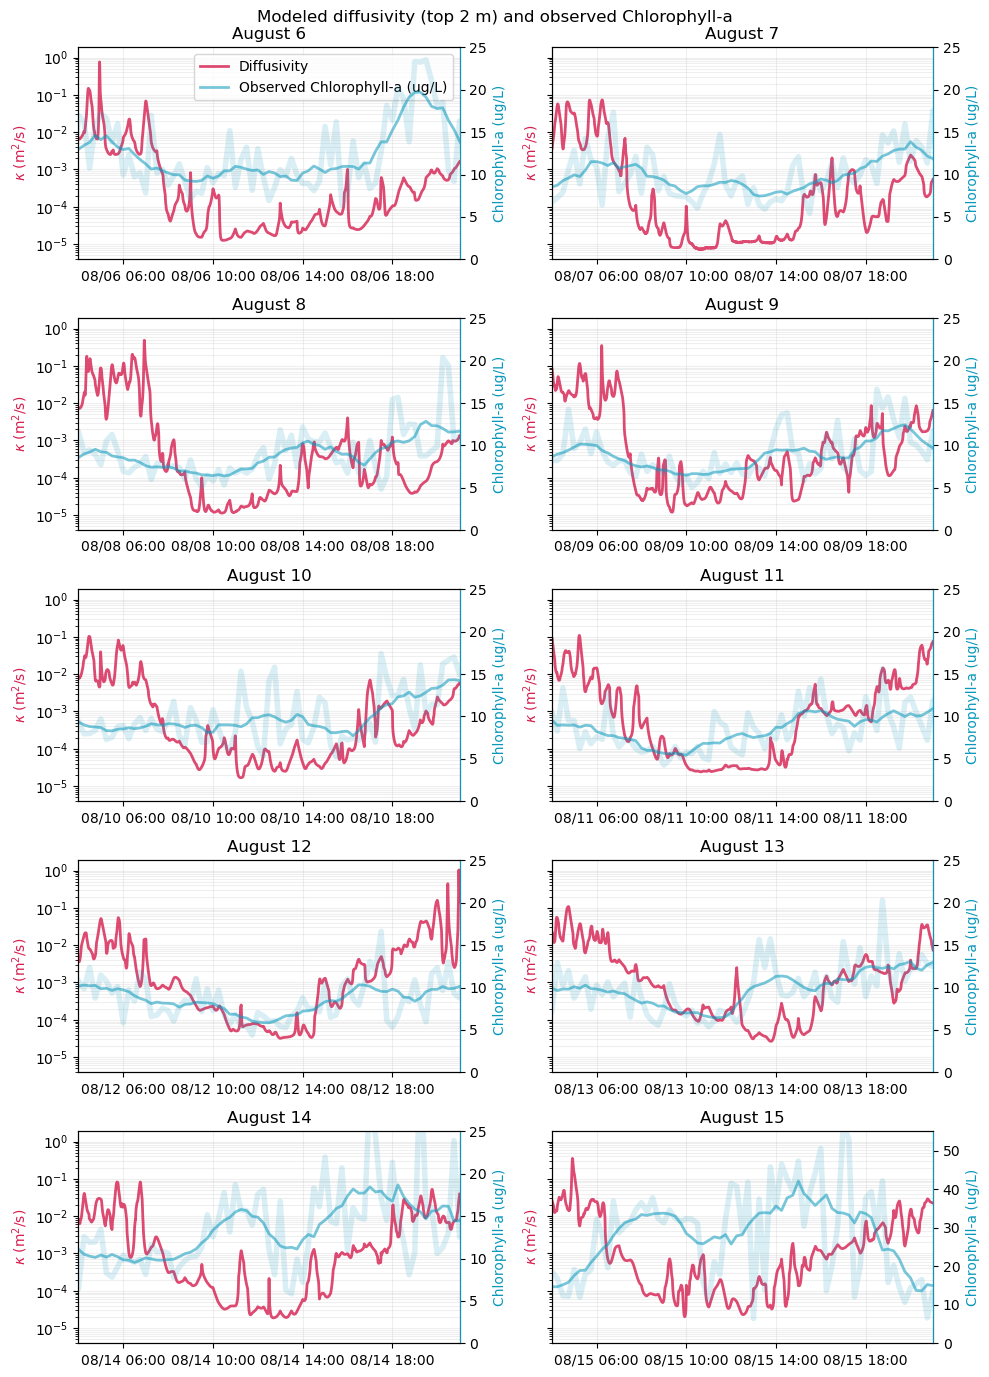

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 14), sharex=False, sharey=True)
axs = axs.flatten()

import matplotlib as mpl 
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)
for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]

    time = Dates[ds.t.values]
    hydro0 = hydro.isel(time=ds.t.values)
    hydro0 = hydro0.sel(z=slice(2, 0))
    kz_ = hydro0.Kz.mean(dim="z")

    h= axs[i].plot(time, kz_, color="#D61E4F", linewidth=2, alpha=0.8, label='Diffusivity')
    ax2= axs[i].twinx()
    ax2.plot(chla.time, obs*1e-3, color="#0998BC", alpha=0.15, linewidth=4, label='Smoothed observed Chlorophyll-a (ug/L)')
    ax2.plot(chla.time, obs_roll*1e-3, color="#0998BC", alpha=0.55, linewidth=2, label='Observed Chlorophyll-a (ug/L)')
    ax2.set_ylim(0,25)
    #Change color of axis
    ax2.set_ylabel("Chlorophyll-a (ug/L)")
    ax2.spines['right'].set_color("#0998BC")
    ax2.yaxis.label.set_color("#0998BC")
    axs[i].set_yscale("log")
    axs[i].grid(True, which="both", alpha=0.2)
    axs[i].set_ylabel("$\kappa$ (m$^2$/s)")
    axs[i].yaxis.label.set_color("#D61E4F")
    # axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.8, color="#3C9FF0") 

    # axs[i].contour(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, levels=[1e-1], linewidths=3 )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    # axs[i].set_ylim(-3, 0)
    axs[i].set_xlim(time[0], time[-1])
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Modeled diffusivity (top 2 m) and observed Chlorophyll-a")
ax2.set_ylim(0, 55)
axs[0].plot([], [], color="#0998BC", alpha=0.55, linewidth=2, label='Observed Chlorophyll-a (ug/L)')

axs[0].legend() 
plt.tight_layout()


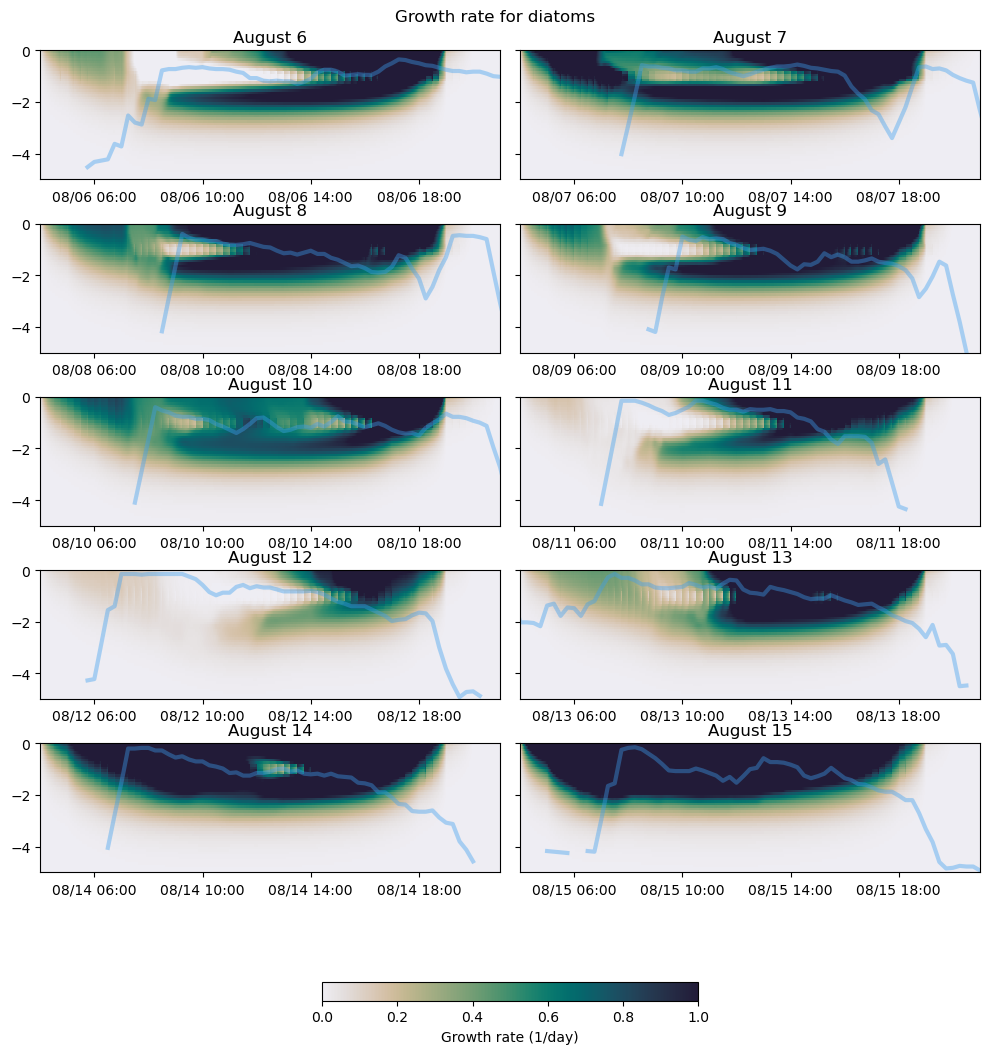

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 12), sharex=False, sharey=True)
axs = axs.flatten()

for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 
    axs[i].set_xlim(time[0], time[-1])

    h = axs[i].pcolormesh(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-5, 0)
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Growth rate for diatoms")

plt.tight_layout()
fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=2e-2)

on day 6
on day 7
on day 8
on day 9
on day 10
on day 11
on day 12
on day 13
on day 14
on day 15


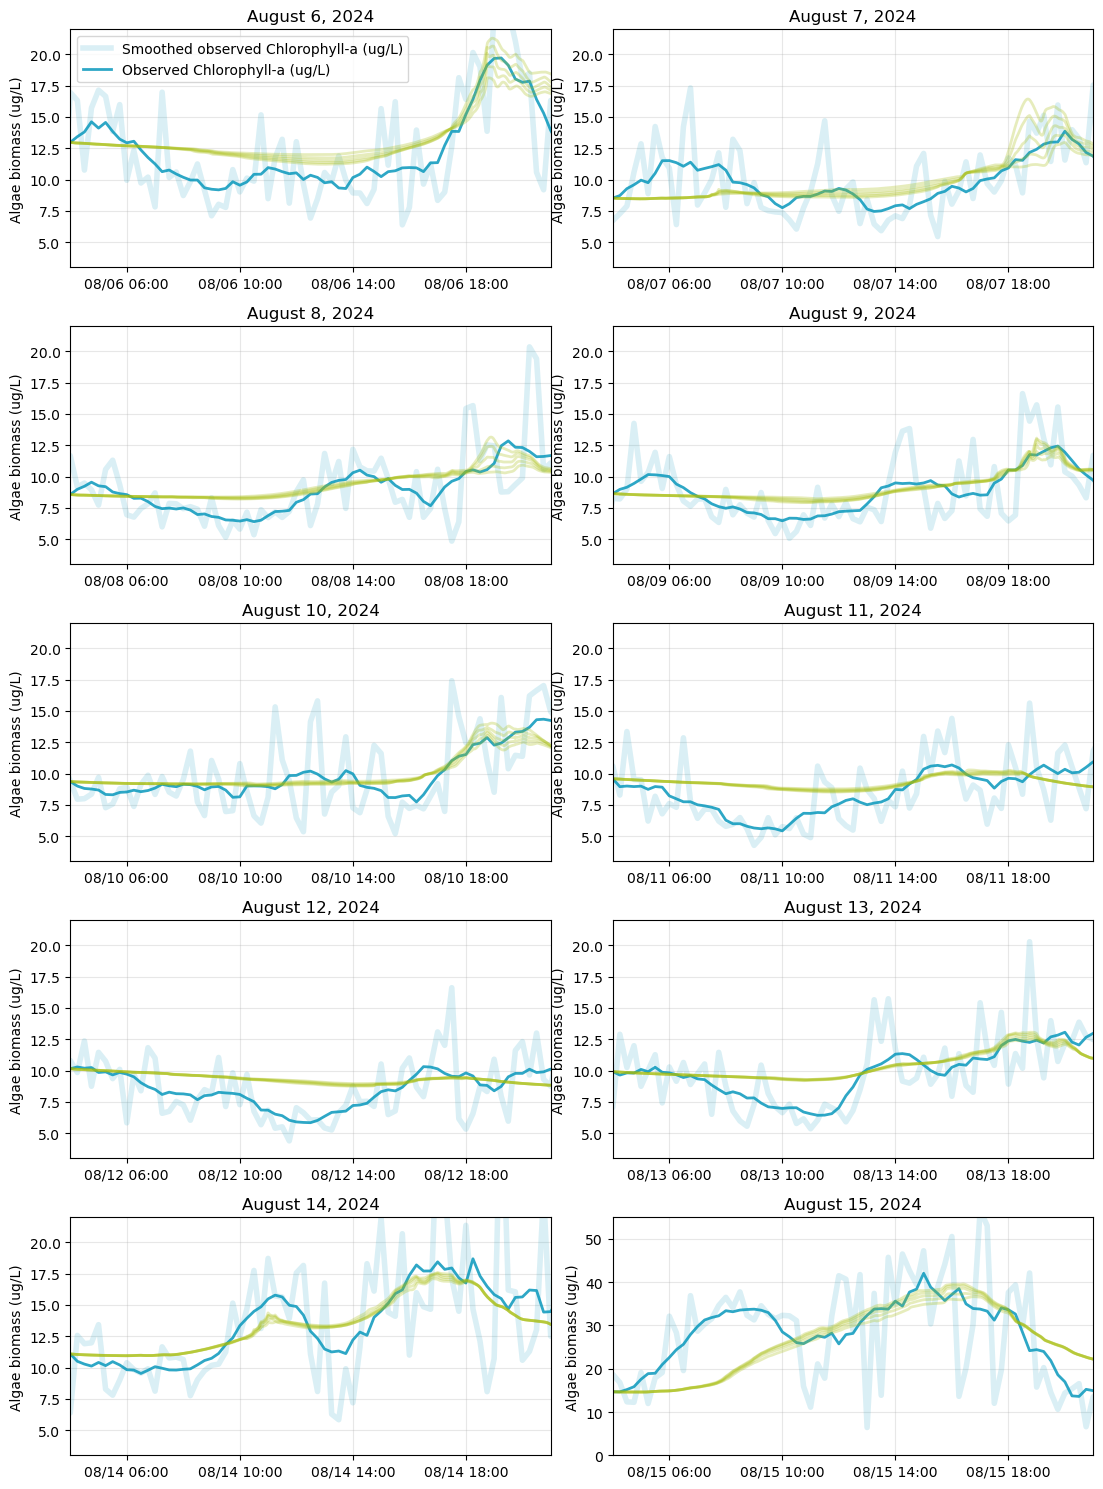

In [ ]:
chla2cell_mc =  1e-6/0.36  # ug chl-a/ml --> pg chl-a/ml --> 0.36  pg chl-a/cell Microcystis
chla2cell_diatom = 1e-6/4 # ug chl-a/ml --> pg chl-a/ml --> 4 pg chl-a/cell Diatom
cell2chla_mc = 1/chla2cell_mc
cell2chla_diatom = 1/chla2cell_diatom



fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(11, 15), sharex=False, sharey=False)
axs = axs.flatten()

for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]
    print("on day", d)
    time = Dates[ds.t.values]
    axs[i].plot(chla.time, obs*1e-3, color="#0998BC", alpha=0.15, linewidth=4, label='Smoothed observed Chlorophyll-a (ug/L)')
    axs[i].plot(chla.time, obs_roll*1e-3, color="#0998BC", alpha=0.85, linewidth=2, label='Observed Chlorophyll-a (ug/L)')
    for iz in range(48,53):
        one_meter_data_N = ds.isel(z=iz)
        total = one_meter_data_N['algae1'].values.T*cell2chla_mc + one_meter_data_N['algae2'].values.T*cell2chla_diatom
        total[-1] = total[-2]
        axs[i].plot(time, total*1e-3, '-',  color='#A6BC09', linewidth=2, alpha=0.27)
    format_date_ax(axs[i])
    axs[i].set_xlim(time[0], time[-1])
    axs[i].set_ylim(3, 22)
    axs[i].grid(alpha=0.3)
    axs[i].set_title("August %d, 2024" % d)
    axs[i].set_ylabel("Algae biomass (ug/L)")

axs[0].legend()

axs[-1].set_ylim(0,55)
plt.tight_layout()

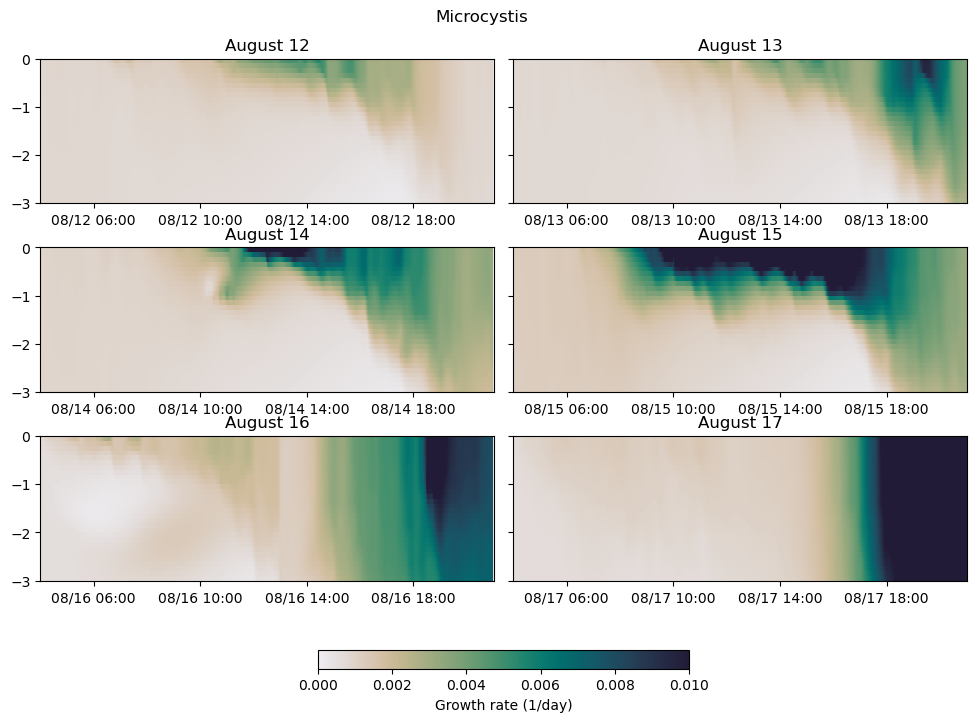

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharex=False, sharey=True)
axs = axs.flatten()

for i,d in enumerate(range(12,18)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    h = axs[i].pcolormesh(time, -z, ds.algae1.values.T, cmap=cmo.cm.rain, vmin=0, vmax=1e-2)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-3, 0)
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Microcystis")

plt.tight_layout()
fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=1e-1)

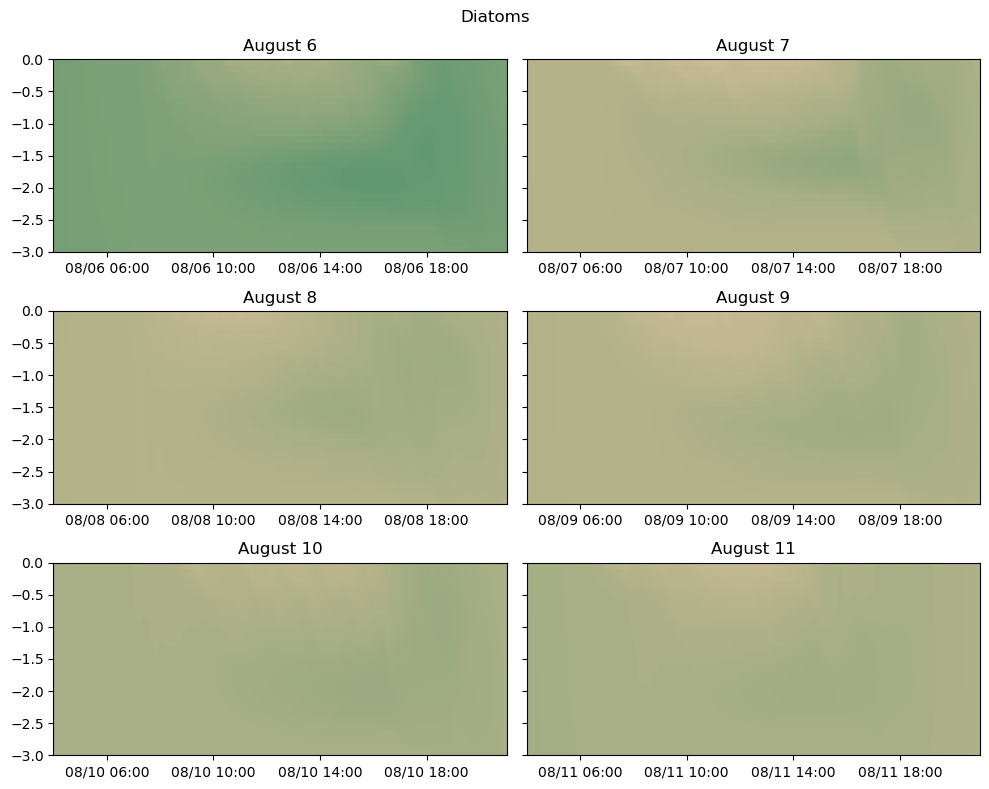

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharex=False, sharey=True)
axs = axs.flatten()

for i,d in enumerate(range(6,12)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    h = axs[i].pcolormesh(time, -z, ds.algae2.values.T, cmap=cmo.cm.rain, vmin=0, vmax=8e-3)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-3, 0)
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Diatoms")

plt.tight_layout()
# fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=1e-1)

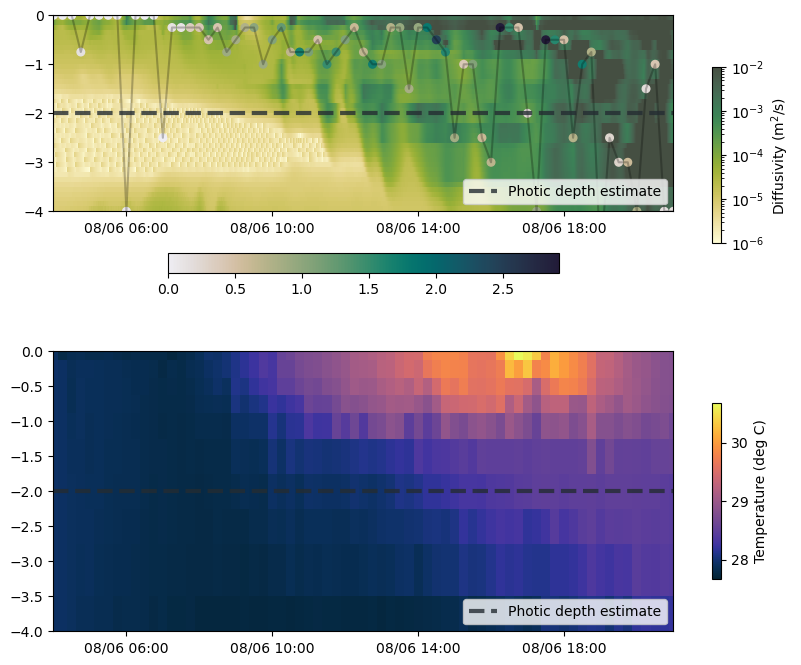

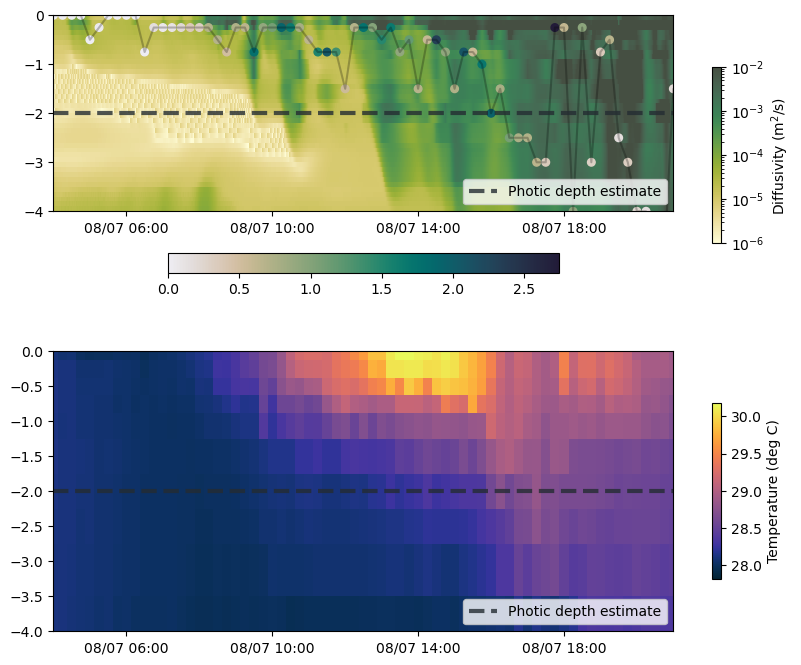

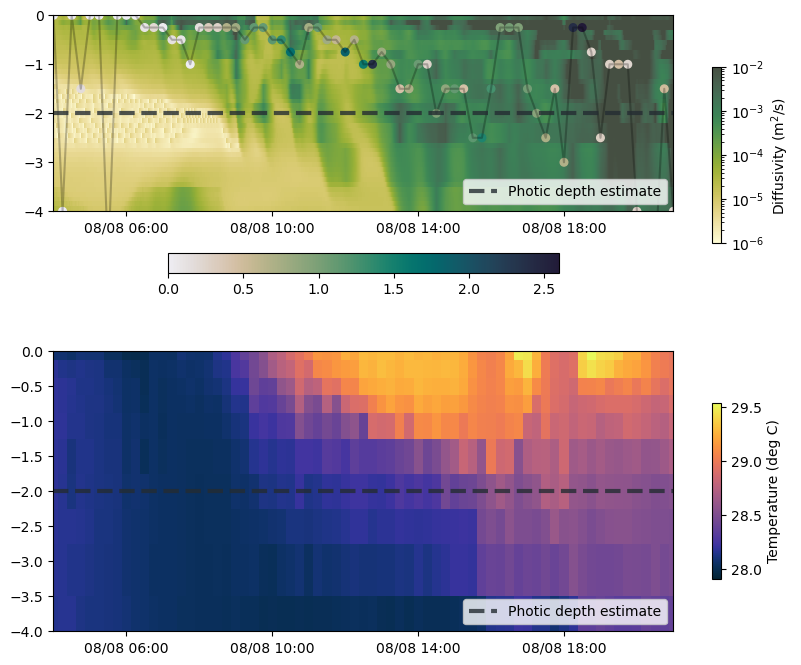

In [ ]:
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(6, 9): 
    temp0 = temp.loc[temp.day == d]

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    # plt.tight_layout()
    # fig.colorbar(h, ax=axs, orientation='horizontal', label='Diffusivity', shrink=0.4, pad=1e-1)

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,8))
    # print(np.min(Z))
    # print(np.max(Z))

    hydro0 = hydro.isel(time=ds.t.values)
    a = axs[0].pcolormesh(time, -z, hydro0.Kz.values.T, cmap=cmo.cm.speed,  norm=norm, alpha=0.8)#, levels=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],) 
    plt.colorbar(a, ax=axs[0], label='Diffusivity (m$^2$/s)', orientation='vertical', shrink = 0.63) 
    # axs[0].contour(X, -Y, Z, cmap=cmo.cm.thermal, vmin=26, vmax=29)

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    # dT[dT<0.2] = np.nan
    # print(np.nanmax(dT, axis=1))
    mixed_d = np.argmax(dT, axis=0)
    # print(mixed_d)
    md = np.array([Y[i] for i in mixed_d])

    maxs = np.nanmax(dT, axis=0)


    
    # dT_ = np.array([dT[i, mixed_d[i]] for i in range(len(mixed_d))])
    # md[md==0] = np.nan
    axs[0].plot(X, -md,"-k", alpha=0.25) #, color='k', linewidth=3, alpha=0.8, label='Max dT/dz')
    c = axs[0].scatter(X, -md, c=maxs, s=30, cmap=cmo.cm.rain) #, color='k', linewidth=3, alpha=0.8, label='Max dT/dz')
    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal) #, vmin=26, vmax=29)
    plt.colorbar(b, ax=axs[1], label='Temperature (deg C)', orientation='vertical', shrink = 0.63) 
    plt.colorbar(c, ax=axs[0],  orientation='horizontal', shrink = 0.63) 

    for ax in axs: 
        # h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
        plt.clabel(h, inline=1, fontsize=10)
        # ax.plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=4, alpha=0.8, color="#3C9FF0", label='Mixed layer depth') 
        ax.hlines(-2, time[0], time[-1], linestyles='--', color="#242C32", linewidth=3, alpha=0.8, label='Photic depth estimate')
        ax.set_xlim(time[0], time[-1])
        format_date_ax(ax)
        ax.legend( loc='lower right')
        ax.set_ylim(-4,0)

/tmp/ipykernel_409908/143943401.py:55: UserWarning: The following kwargs were not used by contour: 'label'
  h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
/tmp/ipykernel_409908/143943401.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend( loc='lower right')


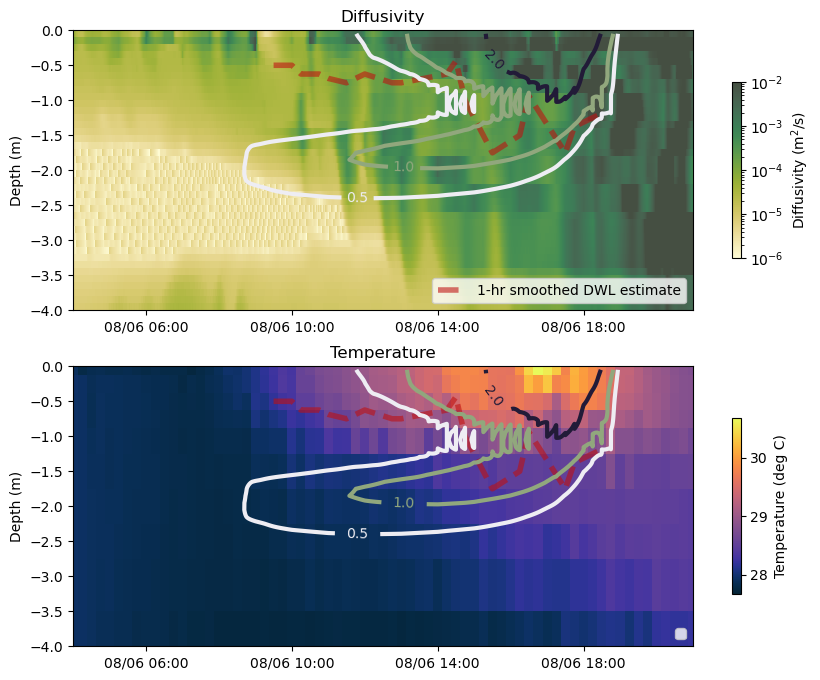

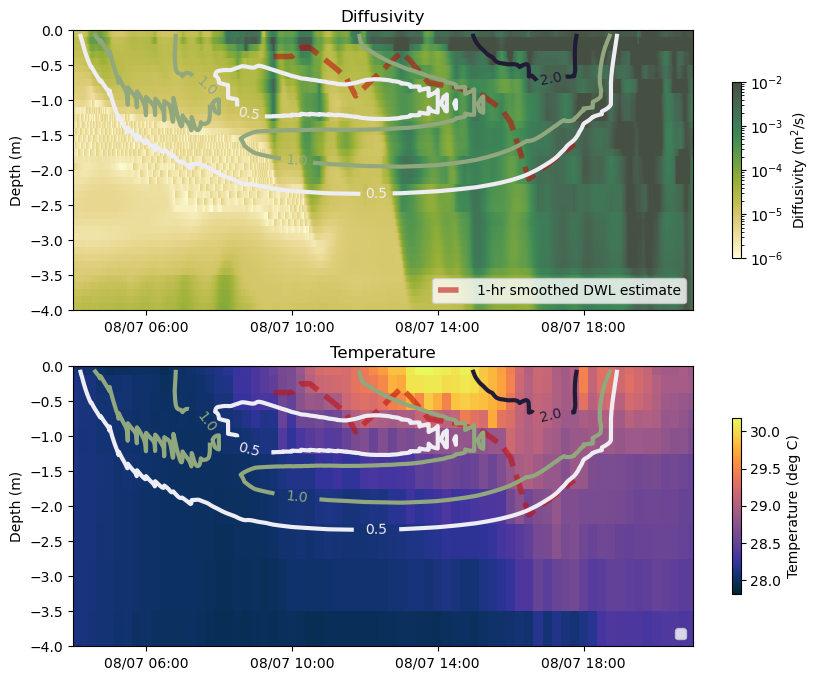

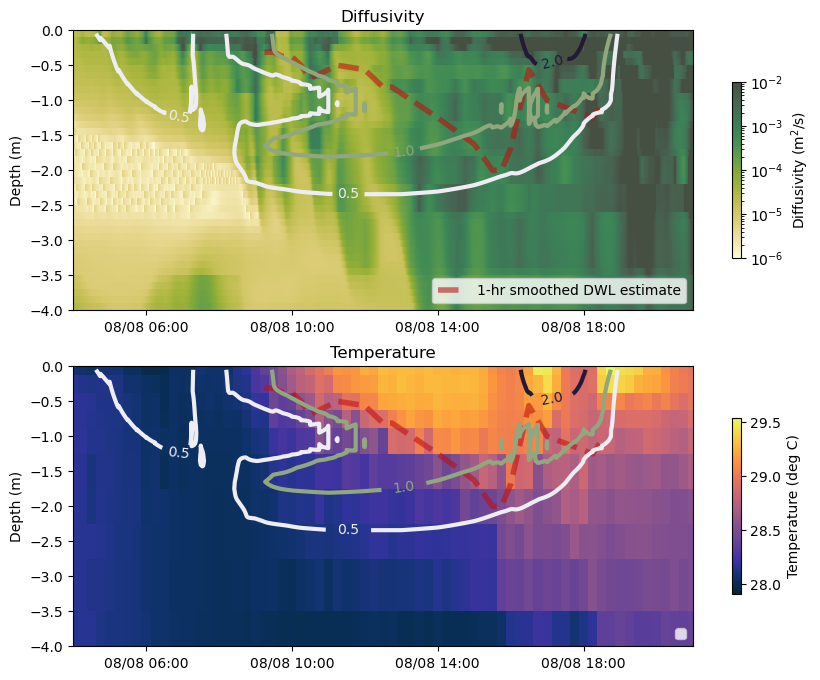

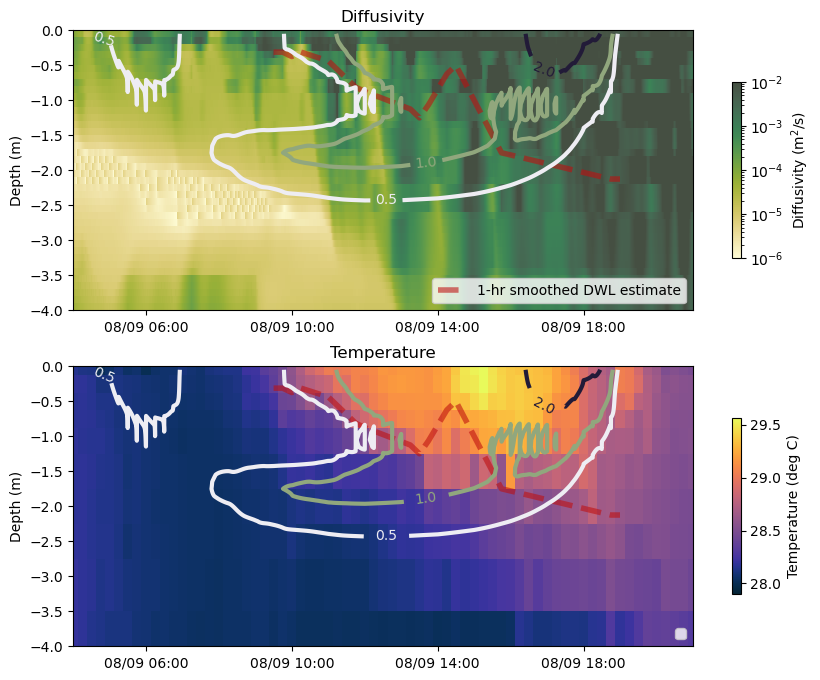

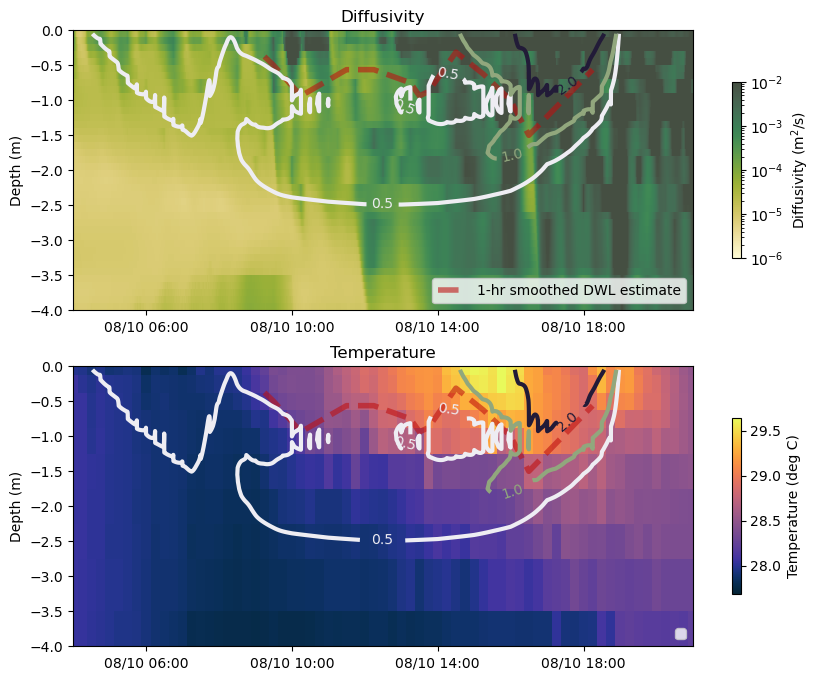

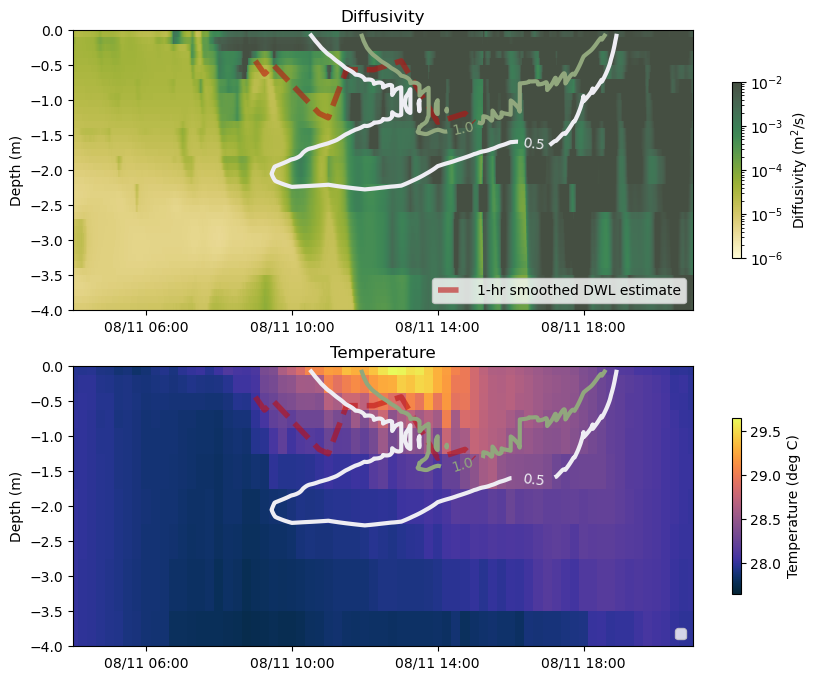

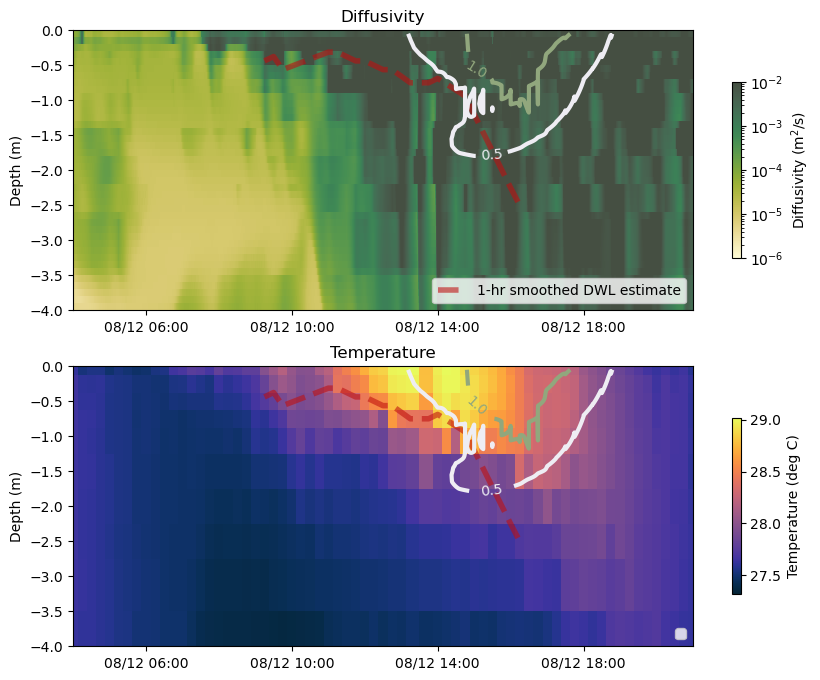

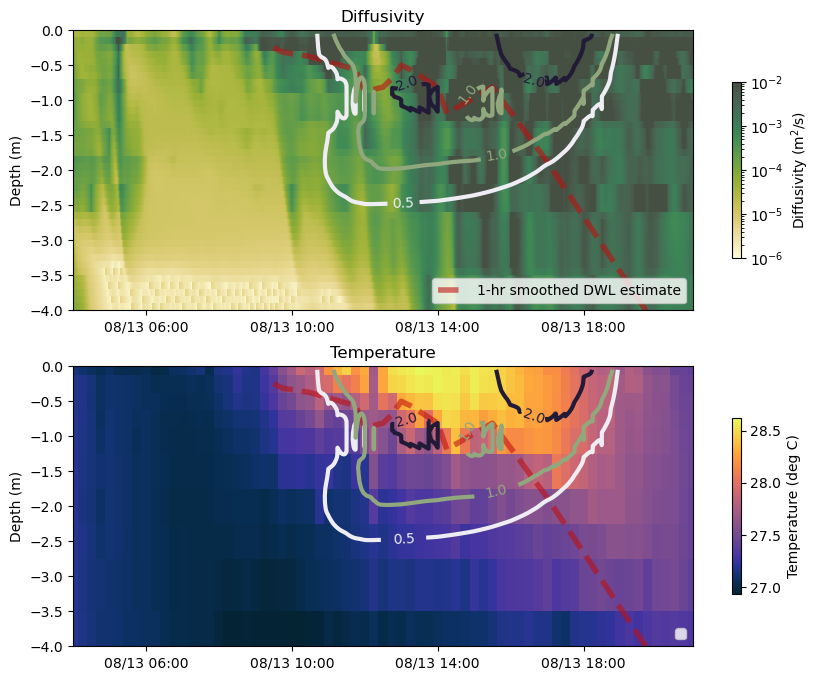

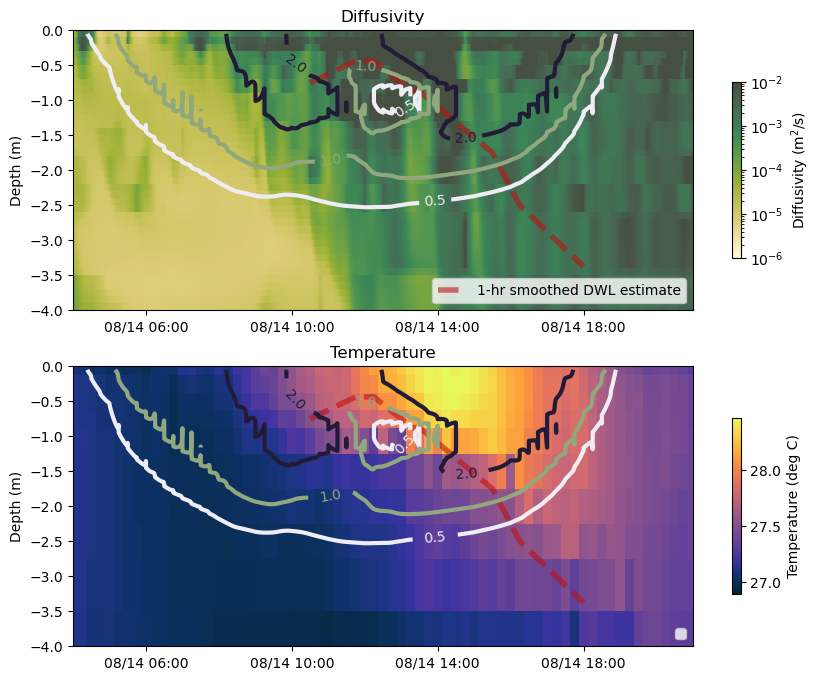

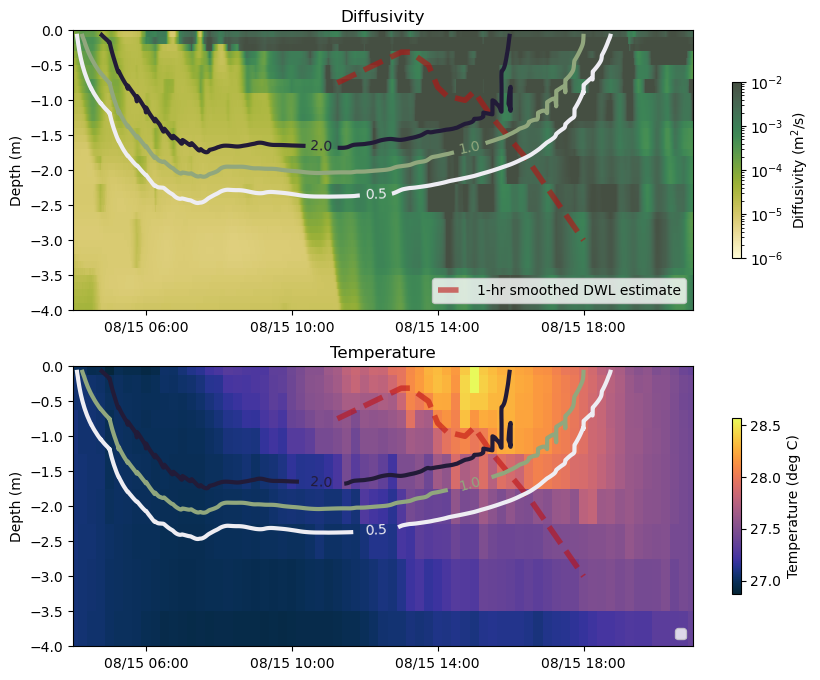

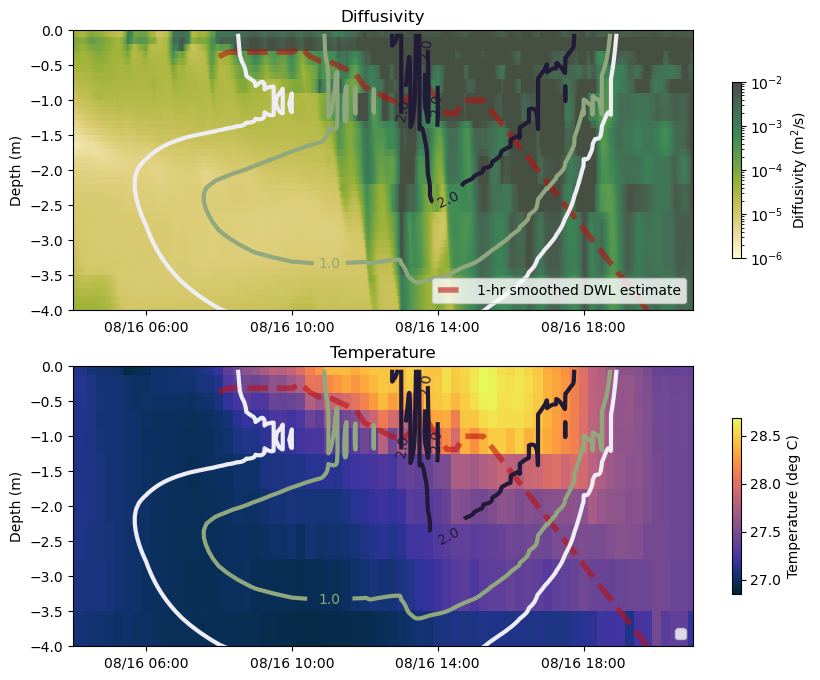

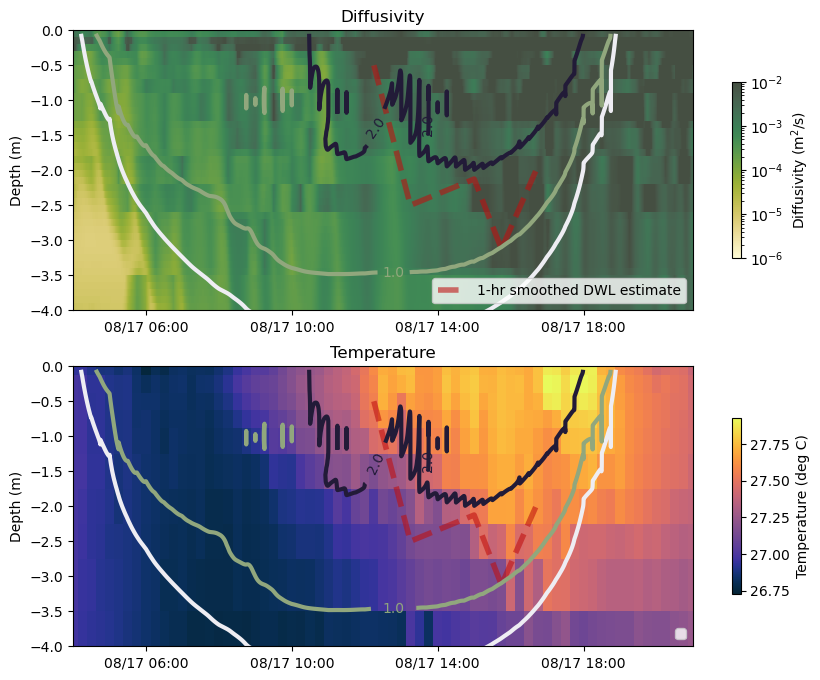

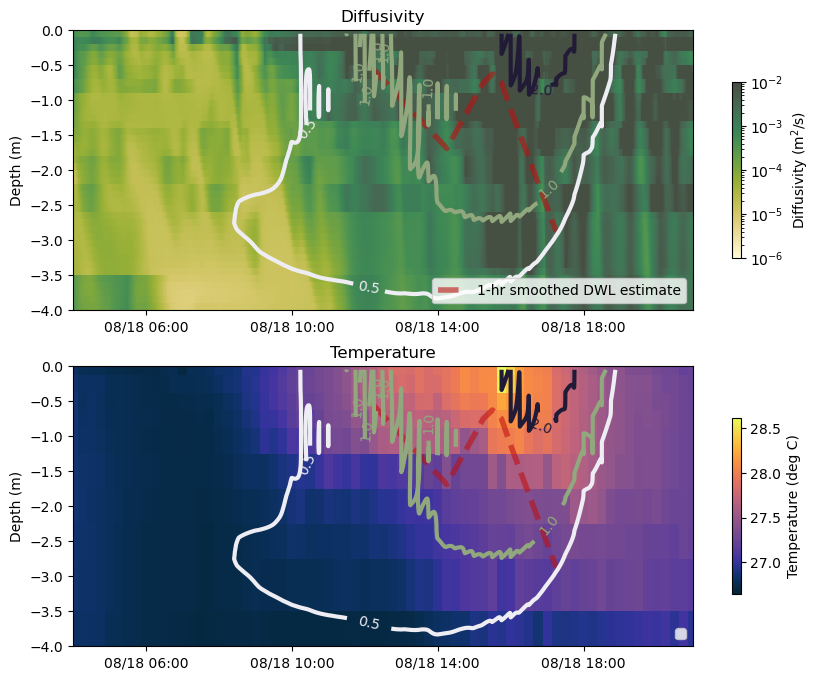

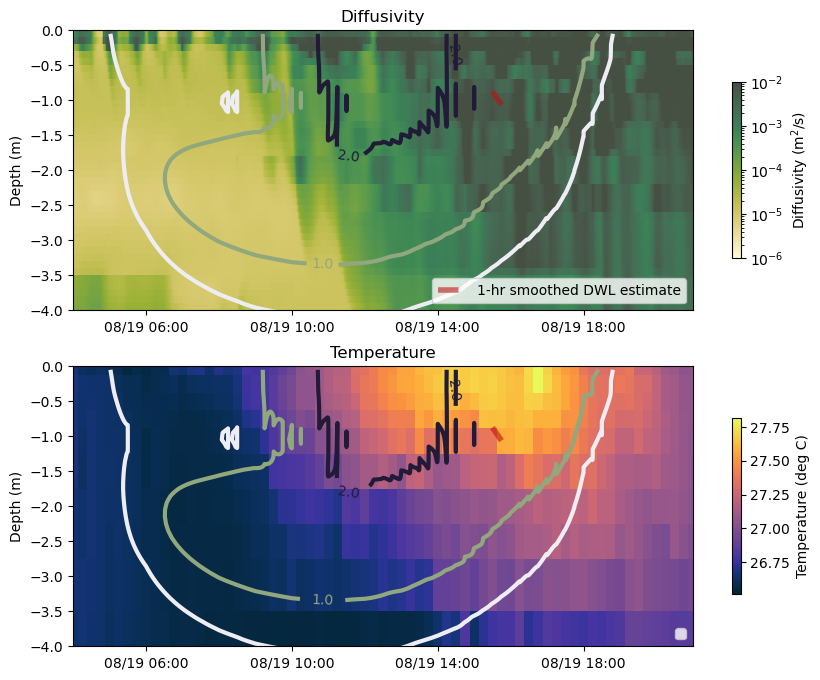

In [ ]:
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(6, 20): 
    temp0 = temp.loc[temp.day == d]

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,8))

    hydro0 = hydro.isel(time=ds.t.values)
    a = axs[0].pcolormesh(time, -z, hydro0.Kz.values.T, cmap=cmo.cm.speed,  norm=norm, alpha=0.8)#, levels=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],) 
    plt.colorbar(a, ax=axs[0], label='Diffusivity (m$^2$/s)', orientation='vertical', shrink = 0.63) 

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])

    maxs = np.nanmax(dT, axis=0)

    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal) #, vmin=26, vmax=29)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    mask = maxs>1
    mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])

    # axs[0].plot(X[mask], -md[mask], color="#E8E366", linewidth=3, alpha=0.28, label="First cut DWL estimate")
    # axs[1].plot(X[mask], -md[mask],  color="#E8E366",linewidth=3, alpha=0.28)
    axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
    axs[0].plot(X[mask], -averaged_md[mask], '--', color="#BF0F0F",linewidth=4, alpha=0.58, label="1-hr smoothed DWL estimate")
    
    # c = axs[0].scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=2) 
    # c = axs[1].scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=2) 

    plt.colorbar(b, ax=axs[1], label='Temperature (deg C)', orientation='vertical', shrink = 0.63) 
    # plt.colorbar(c, ax=axs[1], label="dT/dz" , orientation='horizontal', shrink = 0.43) 
    axs[0].legend()
    axs[0].set_title("Diffusivity")
    axs[1].set_title("Temperature")
    for ax in axs: 
        h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)

        plt.clabel(h, inline=1, fontsize=10)
        # ax.plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=4, alpha=0.8, color="#3C9FF0", label='Mixed layer depth') 
        ax.set_xlim(time[0], time[-1])
        format_date_ax(ax)
        ax.legend( loc='lower right')
        ax.set_ylim(-4,0)
        ax.set_ylabel("Depth (m)")

/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


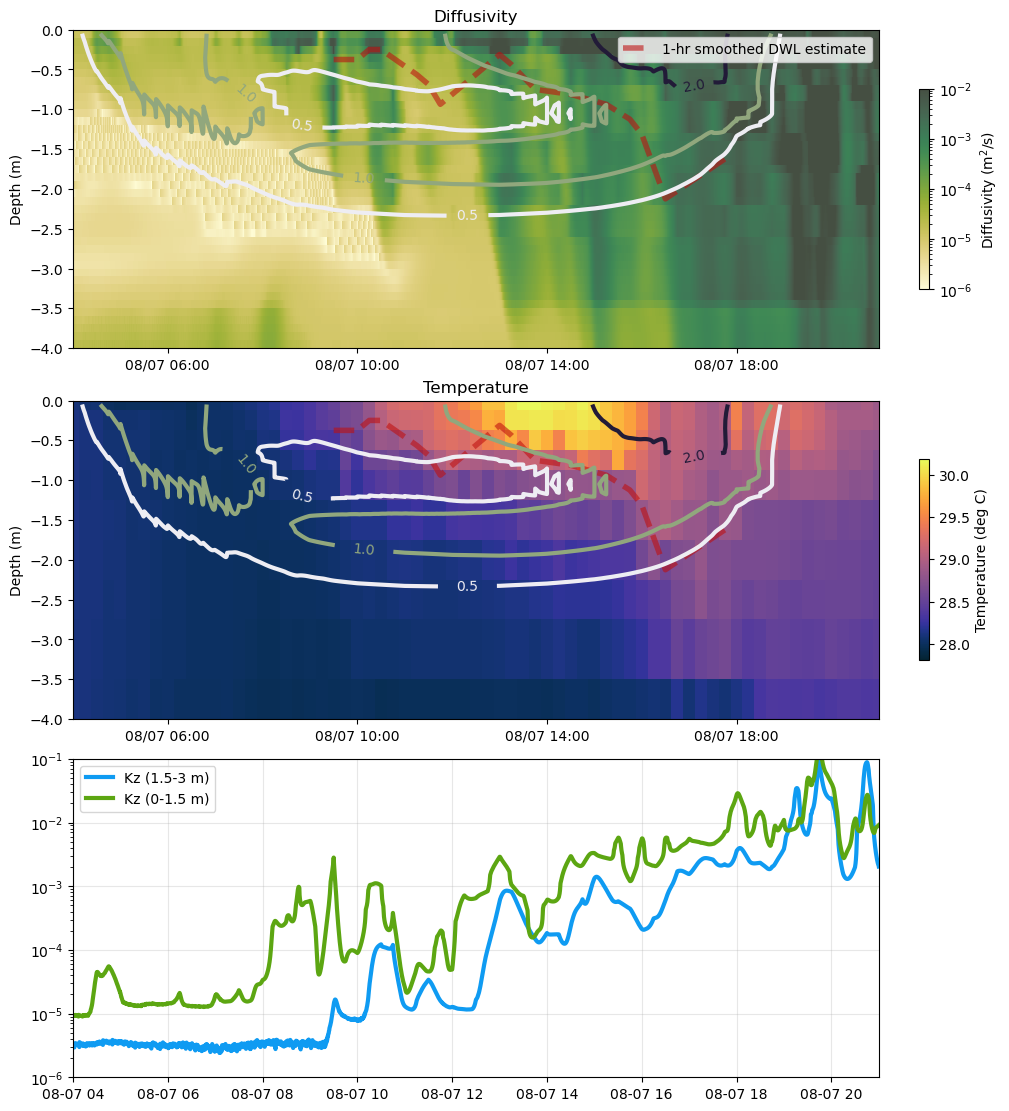

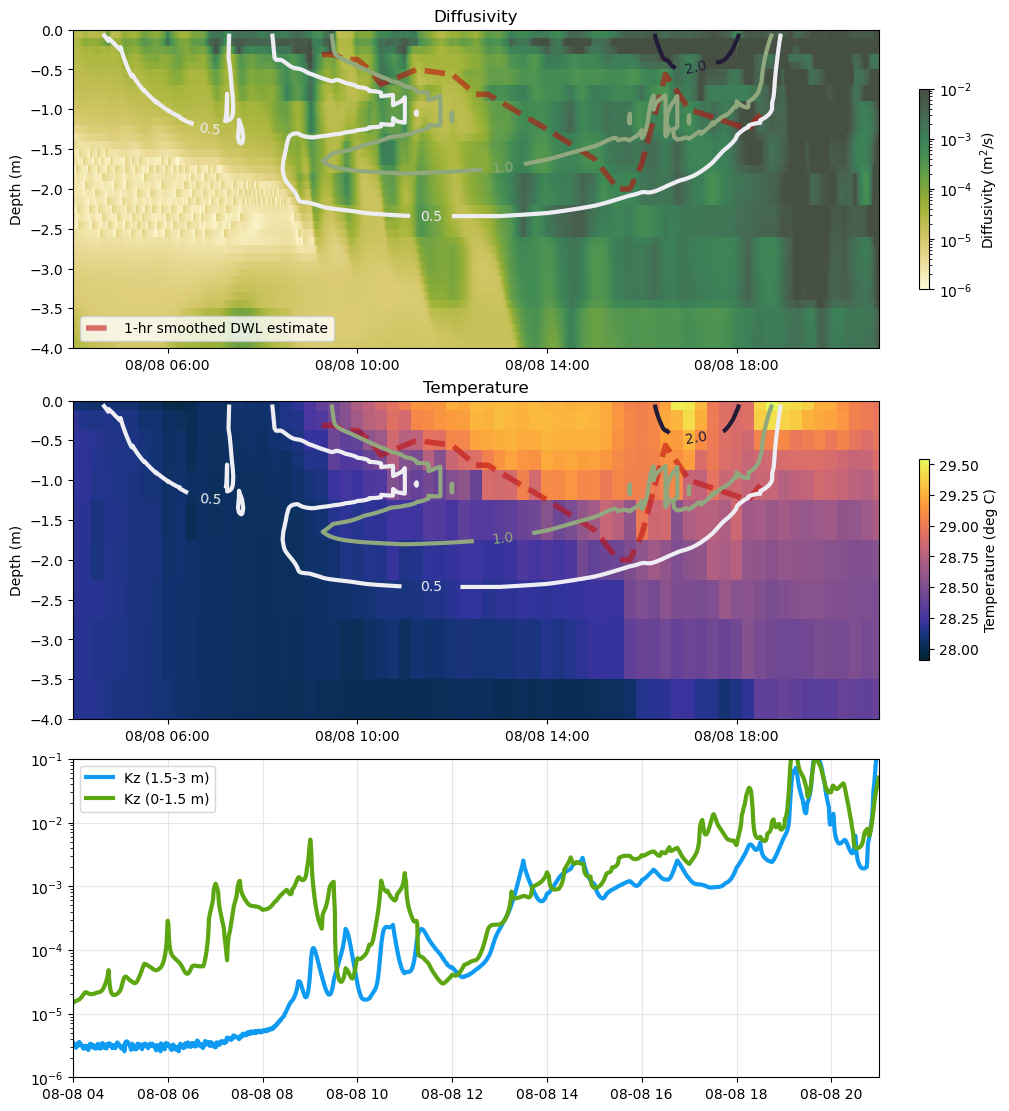

In [ ]:
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(7, 9): 
    temp0 = temp.loc[temp.day == d]

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,11), constrained_layout=True)

    hydro0 = hydro.isel(time=ds.t.values)
    kz = hydro0.Kz.values.T
    a = axs[0].pcolormesh(time, -z, kz, cmap=cmo.cm.speed,  norm=norm, alpha=0.8)#, levels=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],) 
    plt.colorbar(a, ax=axs[0], label='Diffusivity (m$^2$/s)', orientation='vertical', shrink = 0.63) 

    dkz = hydro0.Kz.sel(z=slice(1.5,0)).mean(dim='z')-hydro0.Kz.sel(z=slice(3,1.5)).mean(dim='z')
    axs[2].plot(time, hydro0.Kz.sel(z=slice(3,1.5)).mean(dim='z'), color="#0F9BF2", linewidth=3, label="Kz (1.5-3 m)")
    axs[2].plot(time, hydro0.Kz.sel(z=slice(1.5,0)).mean(dim='z'), color="#5CA612", linewidth=3, label="Kz (0-1.5 m)")

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])

    maxs = np.nanmax(dT, axis=0)

    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal) #, vmin=26, vmax=29)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    mask = maxs>1
    mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])

    axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
    axs[0].plot(X[mask], -averaged_md[mask], '--', color="#BF0F0F",linewidth=4, alpha=0.58, label="1-hr smoothed DWL estimate")
    

    plt.colorbar(b, ax=axs[1], label='Temperature (deg C)', orientation='vertical', shrink = 0.63) 
    axs[0].legend()
    axs[0].set_title("Diffusivity")
    axs[1].set_title("Temperature")
    for ax in axs[0:2]: 
        h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3)#, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)

        plt.clabel(h, inline=1, fontsize=10)
        ax.set_xlim(time[0], time[-1])
        format_date_ax(ax)
        # ax.legend( loc='lower right')
        ax.set_ylim(-4,0)
        ax.set_ylabel("Depth (m)")
    axs[2].set_yscale('log')
    axs[2].set_xlim(time[0], time[-1])
    axs[2].set_ylim(1e-6, 1e-1)
    axs[2].grid(alpha=0.3)
    axs[2].legend()

Text(0, 0.5, 'Depth (m)')

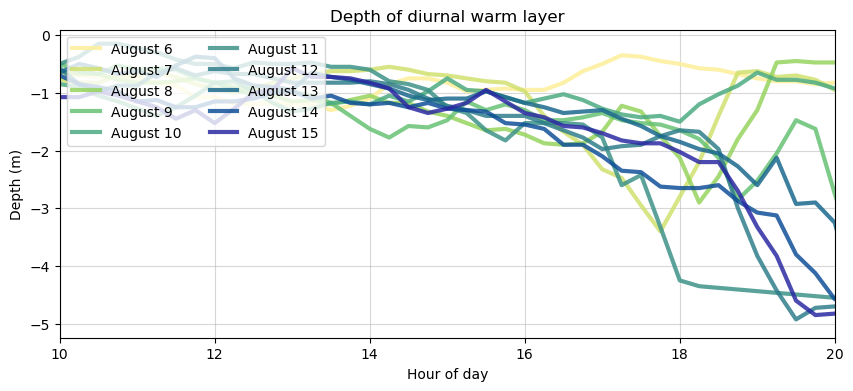

In [ ]:
fig = plt.figure(figsize=(10,4))

mixed_depth['day'] = mixed_depth['time'].dt.day
mixed_depth['hour'] = mixed_depth['time'].dt.hour + mixed_depth['time'].dt.minute/60

for d in range(6, 16): 
    mixed0 = mixed_depth.loc[mixed_depth.day == d]
    plt.plot(mixed0['hour'], -mixed0["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.84, color = cmo.cm.haline_r((d-6)/10), label="August %d" % d) #, color="#3C9

plt.legend(loc ='upper left', ncol=2)
ax = plt.gca()
ax.grid(alpha=0.5)
ax.set_xlim(10, 20)
ax.set_title("Depth of diurnal warm layer")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Depth (m)")

12
13
14
15
16
17
18
19


Text(0, 0.5, 'Normalized Chl-a [-]')

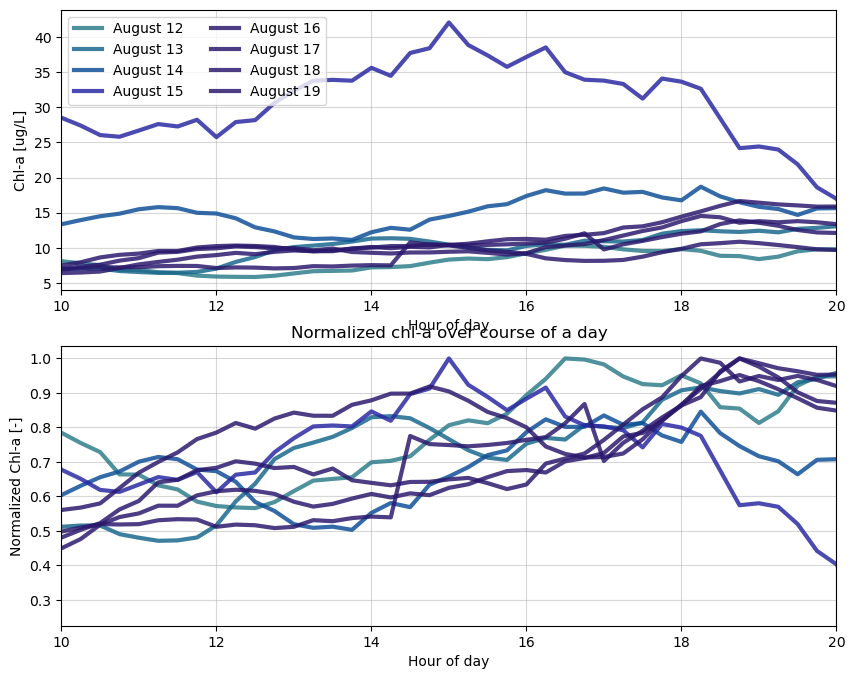

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1 ,figsize=(10,8))
chla['day'] = chla['time'].dt.day
chla['hour'] = chla['time'].dt.hour + chla['time'].dt.minute/60
# print(chla)
for d in range(12, 20): 
    print(d)
    chla0 = chla.loc[chla.day == d]
    axs[1].plot(chla0['hour'], chla0["obs_roll"]/max(chla0["obs_roll"]), '-', linewidth=3, alpha=0.84, color = cmo.cm.haline_r((d-6)/10), label="August %d" % d) #, color="#3C9
    axs[0].plot(chla0['hour'], chla0["obs_roll"]*1e-3, '-', linewidth=3, alpha=0.84, color = cmo.cm.haline_r((d-6)/10), label="August %d" % d) #, color="#3C9

axs[0].legend(loc ='upper left', ncol=2)

for ax in axs:
    ax.grid(alpha=0.5)
    ax.set_xlim(10, 20)
    ax.set_xlabel("Hour of day")
ax.set_title("Normalized chl-a over course of a day")
axs[0].set_ylabel("Chl-a [ug/L]")
axs[1].set_ylabel("Normalized Chl-a [-]")
# ax.set_yscale("log")